In [222]:
## Pacotes utilizados 

## Bibliotecas de importação 
import os 
import tarfile 
import urllib 
import pandas as pd 
import matplotlib as plt 

## Outras bibliotecas para analise de dados e aprendizado de máquina

import numpy as np
import seaborn as sns
import scipy.cluster.hierarchy as sch
import scipy.stats as stats
from scipy.stats import zscore
from scipy.spatial.distance import pdist
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
import pingouin as pg
import plotly.express as px 
import plotly.io as pio
pio.renderers.default='browser'
import prince
from scipy.stats import chi2_contingency
import statsmodels.api as sm
from sklearn.metrics import silhouette_score
from scipy.stats import norm

from scipy.stats import norm
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Importação banco e exploração dos dados: Var cat e numéricas para a análise dos dados 
### Preparação do algoritimo p/ sistema de análise
'''
Sequências de algoritimos: Base Line (Percentual de acerto mínimo do modelo, Algoritmos de inferência para análise de desempenho, 
determinação dos coeficientes significativos em análise, chances de candidato ter êxito para o problema de classificação proposto. Divisão por nível, avaliado para aplicação do modelo Hierárquico.)
'''

In [267]:
## Importação dos datasets: Lista das regiões que foram integradas ao banco para discussão de diferenças de desempenho 
## entre os alunos da capital metropolitana e das mesorregiões 

import pandas as pd
import os

def load_dados_enem_micro(dados_path, file_name):
    """
    Função para carregar um arquivo CSV a partir de um diretório específico.
    
    Parameters:
    dados_path (str): O caminho para o diretório onde os arquivos CSV estão localizados.
    file_name (str): O nome do arquivo CSV a ser carregado.
    
    Returns:
    pd.DataFrame: DataFrame contendo os dados do arquivo CSV.
    """
    # Constrói o caminho completo para o arquivo CSV
    csv_path = os.path.join(dados_path, file_name)
    
    # C
    #Carrega o arquivo CSV em um DataFrame
    return pd.read_csv(csv_path, sep=";", encoding="utf-8", decimal=",", thousands=".")

# Exemplo de uso:
dados_path = "C:/Users/DELL/OneDrive/Documentos/Projeto_revisão_TCC"  # Substitua pelo caminho real
file_name = "Banco_dados_RJ_Mesoregioes_capital_DEP_ADM.csv"

# Detalhes da Amostra

## Regiões  
'''
## Categorias das Mesoregiões 
mesoregioes = {
    'Norte_Fluminense': ['Campos_dos_Goytacazes', 'Sao_Fidelis', 'Sao_Francisco_de_Itabapoana', 'Macae', 'Quissama'],
    'Noroeste_Fluminense': ['Bom_Jesus_do_Itabopoana', 'Itaperuna', 'Itaocara', 'Miracema', 'Santo_Antonio_de_Padua'],
    'Centro_Fluminense': ['Nova_Friburgo', 'Casimiro_de_Abreu', 'Rio_das_Ostras', 'Araruama', 'Cabo_Frio', 'Iguaba_Grande', 'Sao_Pedro_da_Aldeia', 'Saquarema'],
    'Sul_Fluminense': ['Barra_Mansa', 'Itatiaia', 'Resende', 'Rio_claro', 'Volta_Redonda', 'Barra_do_Pirai', 'Valenca', 'Paraty']    
}
'''

## Capital Metropolitana: Rio de Janeiro


# Carrega os dados do arquivo CSV
df_01 = load_dados_enem_micro(dados_path, file_name)

# Exibindo as primeiras linhas do DataFrame para verificar o conteúdo
print(df_01.head())


   NU_INSCRICAO    Q001    Q002    Q003    Q004    Q005    Q006    Q007  \
0  210061234984  Q001_D  Q002_E  Q003_D  Q004_B  Q005_2  Q006_D  Q007_A   
1  210059974463  Q001_B  Q002_D  Q003_C  Q004_B  Q005_4  Q006_B  Q007_A   
2  210058387339  Q001_B  Q002_D  Q003_B  Q004_D  Q005_1  Q006_B  Q007_A   
3  210058073304  Q001_D  Q002_G  Q003_C  Q004_D  Q005_2  Q006_B  Q007_A   
4  210059855138  Q001_B  Q002_D  Q003_C  Q004_B  Q005_4  Q006_A  Q007_B   

     Q008    Q009  ... TP_SEXO TP_DEPENDENCIA_ADM_ESC NO_MUNICIPIO_PROVA  \
0  Q008_C  Q009_C  ...       M                FEDERAL            Valença   
1  Q008_B  Q009_C  ...       F               ESTADUAL     Rio de Janeiro   
2  Q008_B  Q009_B  ...       M                FEDERAL     Rio de Janeiro   
3  Q008_B  Q009_D  ...       F                FEDERAL            Valença   
4  Q008_B  Q009_B  ...       F               ESTADUAL     Rio de Janeiro   

  NU_NOTA_MT NU_NOTA_REDACAO    Q005_z TP_FAIXA_ETARIA_z  \
0      645.6             680 -1.

In [17]:
## Banco de dados
## Notas e desempenhos: Capital e Mesorregiões

In [268]:
df_01.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45089 entries, 0 to 45088
Data columns (total 38 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   NU_INSCRICAO            45089 non-null  int64  
 1   Q001                    45089 non-null  object 
 2   Q002                    45089 non-null  object 
 3   Q003                    45089 non-null  object 
 4   Q004                    45089 non-null  object 
 5   Q005                    45089 non-null  object 
 6   Q006                    45089 non-null  object 
 7   Q007                    45089 non-null  object 
 8   Q008                    45089 non-null  object 
 9   Q009                    45089 non-null  object 
 10  Q010                    45089 non-null  object 
 11  Q012                    45089 non-null  object 
 12  Q013                    45089 non-null  object 
 13  Q014                    45089 non-null  object 
 14  Q015                    45089 non-null

In [225]:
df_01['Mesorregiao'].value_counts()

Mesorregiao
Capital Metropolitana    33758
Sul Fluminense            3957
Centro Fluminense         3571
Norte Fluminense          2648
Noroeste Fluminense       1155
Name: count, dtype: int64

In [269]:
Educacao_enem_bin_mt_muni_02 = df_01

In [227]:
## Divisão final entre as regiões: testes aferidos em Spyder, para identificação de agrupamentos de variáveis - K-means ou 
## outros aspectos que levassem a progressão no estudo - Análise Factorial com dados mistos, quantitativos e qualitativos categóricos 
## do questionário social - nome dos datasets vinculado a testes do banco de dados eferido antes da formatação final do objeto 

Educacao_enem_bin_mt_muni_02_RJ = Educacao_enem_bin_mt_muni_02[Educacao_enem_bin_mt_muni_02['Mesorregiao'] == 'Capital Metropolitana']
Educacao_enem_bin_mt_muni_02_Meso = Educacao_enem_bin_mt_muni_02[Educacao_enem_bin_mt_muni_02['Mesorregiao'] != 'Capital Metropolitana']
df_01.isna()
total_missing = df_01.isnull().sum().sum()
print(total_missing) ## RETIRADA DOS VALORES FALTANTES, ALUNOS FALTANTES E DOS QUE TIRARAM ZERO NA PROVA DO EXAME NACIONAL 

84


In [228]:
## Capital: 
Educacao_enem_bin_mt_muni_02_RJ

,NU_INSCRICAO,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,...,TP_SEXO,TP_DEPENDENCIA_ADM_ESC,NO_MUNICIPIO_PROVA,NU_NOTA_MT,NU_NOTA_REDACAO,Q005_z,TP_FAIXA_ETARIA_z,Mesorregiao,NO_MUNICIPIO_PROVA_N,NO_MUNICIPIO_PROVA_PAD
1,210059974463,Q001_B,Q002_D,Q003_C,Q004_B,Q005_4,Q006_B,Q007_A,Q008_B,Q009_C,...,F,ESTADUAL,Rio de Janeiro,365.3,680,0.151517,-0.311344,Capital Metropolitana,,RIO DE JANEIRO
2,210058387339,Q001_B,Q002_D,Q003_B,Q004_D,Q005_1,Q006_B,Q007_A,Q008_B,Q009_B,...,M,FEDERAL,Rio de Janeiro,636.8,820,-2.048422,1.066768,Capital Metropolitana,,RIO DE JANEIRO
4,210059855138,Q001_B,Q002_D,Q003_C,Q004_B,Q005_4,Q006_A,Q007_B,Q008_B,Q009_B,...,F,ESTADUAL,Rio de Janeiro,396.7,480,0.151517,-0.311344,Capital Metropolitana,,RIO DE JANEIRO
5,210059897897,Q001_H,Q002_E,Q003_C,Q004_B,Q005_3,Q006_C,Q007_A,Q008_B,Q009_C,...,F,ESTADUAL,Rio de Janeiro,364.3,840,-0.581796,-0.770714,Capital Metropolitana,,RIO DE JANEIRO
6,210058387357,Q001_E,Q002_G,Q003_F,Q004_D,Q005_3,Q006_D,Q007_A,Q008_B,Q009_B,...,F,PRIVADA,Rio de Janeiro,491.5,740,-0.581796,-0.311344,Capital Metropolitana,,RIO DE JANEIRO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45082,210059387403,Q001_E,Q002_G,Q003_D,Q004_E,Q005_4,Q006_O,Q007_A,Q008_D,Q009_D,...,M,PRIVADA,Rio de Janeiro,792.2,640,0.151517,-0.770714,Capital Metropolitana,,RIO DE JANEIRO
45083,210059477597,Q001_E,Q002_F,Q003_D,Q004_D,Q005_4,Q006_E,Q007_A,Q008_B,Q009_C,...,M,ESTADUAL,Rio de Janeiro,669.2,520,0.151517,-0.311344,Capital Metropolitana,,RIO DE JANEIRO
45085,210059634615,Q001_E,Q002_E,Q003_C,Q004_F,Q005_3,Q006_F,Q007_A,Q008_B,Q009_C,...,F,PRIVADA,Rio de Janeiro,828.7,740,-0.581796,-0.770714,Capital Metropolitana,,RIO DE JANEIRO
45086,210061345765,Q001_E,Q002_E,Q003_F,Q004_D,Q005_3,Q006_C,Q007_A,Q008_B,Q009_C,...,F,ESTADUAL,São João de Meriti,455.5,760,-0.581796,-0.770714,Capital Metropolitana,,SAO JOAO DE MERITI


In [229]:
## Mesorregiões
Educacao_enem_bin_mt_muni_02_Meso

,NU_INSCRICAO,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,...,TP_SEXO,TP_DEPENDENCIA_ADM_ESC,NO_MUNICIPIO_PROVA,NU_NOTA_MT,NU_NOTA_REDACAO,Q005_z,TP_FAIXA_ETARIA_z,Mesorregiao,NO_MUNICIPIO_PROVA_N,NO_MUNICIPIO_PROVA_PAD
0,210061234984,Q001_D,Q002_E,Q003_D,Q004_B,Q005_2,Q006_D,Q007_A,Q008_C,Q009_C,...,M,FEDERAL,Valença,645.6,680,-1.315109,-0.311344,Sul Fluminense,,VALENCA
3,210058073304,Q001_D,Q002_G,Q003_C,Q004_D,Q005_2,Q006_B,Q007_A,Q008_B,Q009_D,...,F,FEDERAL,Valença,648.8,880,-1.315109,0.148027,Sul Fluminense,,VALENCA
8,210059993982,Q001_B,Q002_C,Q003_A,Q004_B,Q005_4,Q006_E,Q007_A,Q008_B,Q009_D,...,F,ESTADUAL,Paraty,384.1,320,0.151517,-0.311344,Sul Fluminense,,PARATY
9,210058573855,Q001_G,Q002_F,Q003_D,Q004_D,Q005_5,Q006_J,Q007_A,Q008_C,Q009_D,...,F,ESTADUAL,São Fidélis,701.3,860,0.884830,-0.311344,Norte Fluminense,,SAO FIDELIS
15,210059401180,Q001_E,Q002_E,Q003_C,Q004_F,Q005_8,Q006_E,Q007_A,Q008_B,Q009_D,...,F,ESTADUAL,Nova Friburgo,384.5,600,3.084769,-0.311344,Centro Fluminense,,NOVA FRIBURGO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45074,210059112393,Q001_E,Q002_F,Q003_C,Q004_D,Q005_3,Q006_G,Q007_A,Q008_C,Q009_C,...,M,FEDERAL,Rio das Ostras,677.5,620,-0.581796,-0.311344,Centro Fluminense,,RIO DAS OSTRAS
45077,210060069349,Q001_H,Q002_E,Q003_F,Q004_B,Q005_3,Q006_C,Q007_A,Q008_C,Q009_C,...,M,ESTADUAL,São Pedro da Aldeia,416.6,660,-0.581796,-0.311344,Centro Fluminense,,SAO PEDRO DA ALDEIA
45079,210061345757,Q001_D,Q002_E,Q003_B,Q004_B,Q005_4,Q006_B,Q007_A,Q008_B,Q009_C,...,F,ESTADUAL,Itaperuna,441.4,500,0.151517,-0.770714,Noroeste Fluminense,,ITAPERUNA
45084,210059003779,Q001_E,Q002_E,Q003_B,Q004_B,Q005_3,Q006_C,Q007_A,Q008_B,Q009_D,...,F,ESTADUAL,Resende,633.4,620,-0.581796,-0.311344,Sul Fluminense,,RESENDE


In [230]:
## Contagem das variáveis de exploração, vinculadas a testes estatísticos e que fizeram parte dos preditores finais 
import pandas as pd

# Supondo que 'Educacao_enem_bin_mt_muni_02_RJ' já esteja carregado como um DataFrame
def contar_categorias(df, colunas):
    for coluna in colunas:
        print(f"Contagem para a variável {coluna}:")
        print(df[coluna].value_counts())
        print("\n")  # Linha em branco para separar os resultados

# Lista das variáveis que você quer contar
variaveis = [
    'Q025', 'Q024', 'Q023', 'Q022', 'Q021', 'Q020', 'Q019', 'Q018', 'Q017', 'Q016', 'Q015', 'Q014',
    'Q013', 'Q012', 'Q010', 'Q009', 'Q008', 'Q007', 'Q006', 'Q005', 'Q004', 'Q003', 
    'Q002', 'Q001'
]

# Chamando a função para contar as categorias
contar_categorias(Educacao_enem_bin_mt_muni_02_RJ, variaveis)


Contagem para a variável Q025:
Q025
Q025_B    32454
Q025_A     1304
Name: count, dtype: int64


Contagem para a variável Q024:
Q024
Q024_B    13567
Q024_A    10849
Q024_C     5173
Q024_D     2582
Q024_E     1587
Name: count, dtype: int64


Contagem para a variável Q023:
Q023
A    26732
B     7026
Name: count, dtype: int64


Contagem para a variável Q022:
Q022
Q022_D    12142
Q022_E    10271
Q022_C     7317
Q022_B     3201
Q022_A      827
Name: count, dtype: int64


Contagem para a variável Q021:
Q021
Q021_A    19395
Q021_B    14363
Name: count, dtype: int64


Contagem para a variável Q020:
Q020
Q020_A    26821
Q020_B     6937
Name: count, dtype: int64


Contagem para a variável Q019:
Q019
Q019_B    15685
Q019_C     9174
Q019_D     5331
Q019_E     2861
Q019_A      707
Name: count, dtype: int64


Contagem para a variável Q018:
Q018
Q018_A    20181
Q018_B    13577
Name: count, dtype: int64


Contagem para a variável Q017:
Q017
Q017_A    31812
Q017_B     1912
Q017_C       32
Q017_D        

In [231]:
## Contagem das variáveis de exploração, vinculadas a testes estatísticos e que fizeram parte dos preditores finais 
import pandas as pd

# Supondo que 'Educacao_enem_bin_mt_muni_02_RJ' já esteja carregado como um DataFrame
def contar_categorias(df, colunas):
    for coluna in colunas:
        print(f"Contagem para a variável {coluna}:")
        print(df[coluna].value_counts())
        print("\n")  # Linha em branco para separar os resultados

# Lista das variáveis que você quer contar
variaveis = [
    'TP_SEXO', 'TP_COR_RACA', 'TP_ESCOLA' 
]

# Chamando a função para contar as categorias
contar_categorias(Educacao_enem_bin_mt_muni_02_RJ, variaveis)

Contagem para a variável TP_SEXO:
TP_SEXO
F    19187
M    14571
Name: count, dtype: int64


Contagem para a variável TP_COR_RACA:
TP_COR_RACA
BRANCA     18639
PARDA      10046
PRETA       4726
AMARELA      284
Name: count, dtype: int64


Contagem para a variável TP_ESCOLA:
TP_ESCOLA
COLEGIO_PUBLICO    17319
COLEGIO_PRIVADO    16439
Name: count, dtype: int64




In [232]:
## Contagem das variáveis de exploração, vinculadas a testes estatísticos e que fizeram parte dos preditores finais 
import pandas as pd
## Código com auxílio GPT
# Supondo que 'Educacao_enem_bin_mt_muni_02_RJ' já esteja carregado como um DataFrame
def contar_categorias(df, colunas):
    for coluna in colunas:
        print(f"Contagem para a variável {coluna}:")
        print(df[coluna].value_counts())
        print("\n")  # Linha em branco para separar os resultados

# Lista das variáveis que você quer contar
variaveis = [
    'Q025', 'Q024', 'Q023', 'Q022', 'Q021', 'Q020', 'Q019', 'Q018', 'Q017', 'Q016', 'Q015', 'Q014',
    'Q013', 'Q012', 'Q010', 'Q009', 'Q008', 'Q007', 'Q006', 'Q005', 'Q004', 'Q003', 
    'Q002', 'Q001'
]

# Chamando a função para contar as categorias
contar_categorias(Educacao_enem_bin_mt_muni_02_Meso, variaveis)

Contagem para a variável Q025:
Q025
Q025_B    11033
Q025_A      298
Name: count, dtype: int64


Contagem para a variável Q024:
Q024
Q024_B    4918
Q024_A    4021
Q024_C    1606
Q024_D     554
Q024_E     232
Name: count, dtype: int64


Contagem para a variável Q023:
Q023
A    9768
B    1563
Name: count, dtype: int64


Contagem para a variável Q022:
Q022
Q022_D    4243
Q022_E    3534
Q022_C    2393
Q022_B     916
Q022_A     245
Name: count, dtype: int64


Contagem para a variável Q021:
Q021
Q021_A    7619
Q021_B    3712
Name: count, dtype: int64


Contagem para a variável Q020:
Q020
Q020_A    9334
Q020_B    1997
Name: count, dtype: int64


Contagem para a variável Q019:
Q019
Q019_B    5807
Q019_C    3010
Q019_D    1427
Q019_E     727
Q019_A     360
Name: count, dtype: int64


Contagem para a variável Q018:
Q018
Q018_A    7147
Q018_B    4184
Name: count, dtype: int64


Contagem para a variável Q017:
Q017
Q017_A    10895
Q017_B      429
Q017_C        6
Q017_E        1
Name: count, dtype: i

In [233]:
## Contagem das variáveis de exploração, vinculadas a testes estatísticos e que fizeram parte dos preditores finais 
import pandas as pd

# Supondo que 'Educacao_enem_bin_mt_muni_02_RJ' já esteja carregado como um DataFrame
def contar_categorias(df, colunas):
    for coluna in colunas:
        print(f"Contagem para a variável {coluna}:")
        print(df[coluna].value_counts())
        print("\n")  # Linha em branco para separar os resultados

# Lista das variáveis que você quer contar
variaveis = [
    'TP_SEXO', 'TP_COR_RACA', 'TP_ESCOLA' 
]

# Chamando a função para contar as categorias
contar_categorias(Educacao_enem_bin_mt_muni_02_Meso, variaveis)

Contagem para a variável TP_SEXO:
TP_SEXO
F    6435
M    4896
Name: count, dtype: int64


Contagem para a variável TP_COR_RACA:
TP_COR_RACA
BRANCA     6533
PARDA      3270
PRETA      1420
AMARELA      87
Name: count, dtype: int64


Contagem para a variável TP_ESCOLA:
TP_ESCOLA
COLEGIO_PUBLICO    7387
COLEGIO_PRIVADO    3944
Name: count, dtype: int64




In [234]:
print(df_01["NU_NOTA_MT"].describe())
# Se aparecerem valores > 1000, ainda há linhas mal convertidas

count    45089.000000
mean       579.255473
std        127.431628
min        324.400000
25%        477.300000
50%        581.200000
75%        677.300000
max        958.600000
Name: NU_NOTA_MT, dtype: float64


## CATEGORIA POR REGIÃO: CAPITAL DO RIO DE JANEIRO E MESORREGIÕES -> Exploração dos dados 
#### Gráficos Box-Plots var categoricas Pela ordem - Capital Metropolitana - Datset de análise: Municipios sem padronização - Var preditoras

## MATEMÁTICA

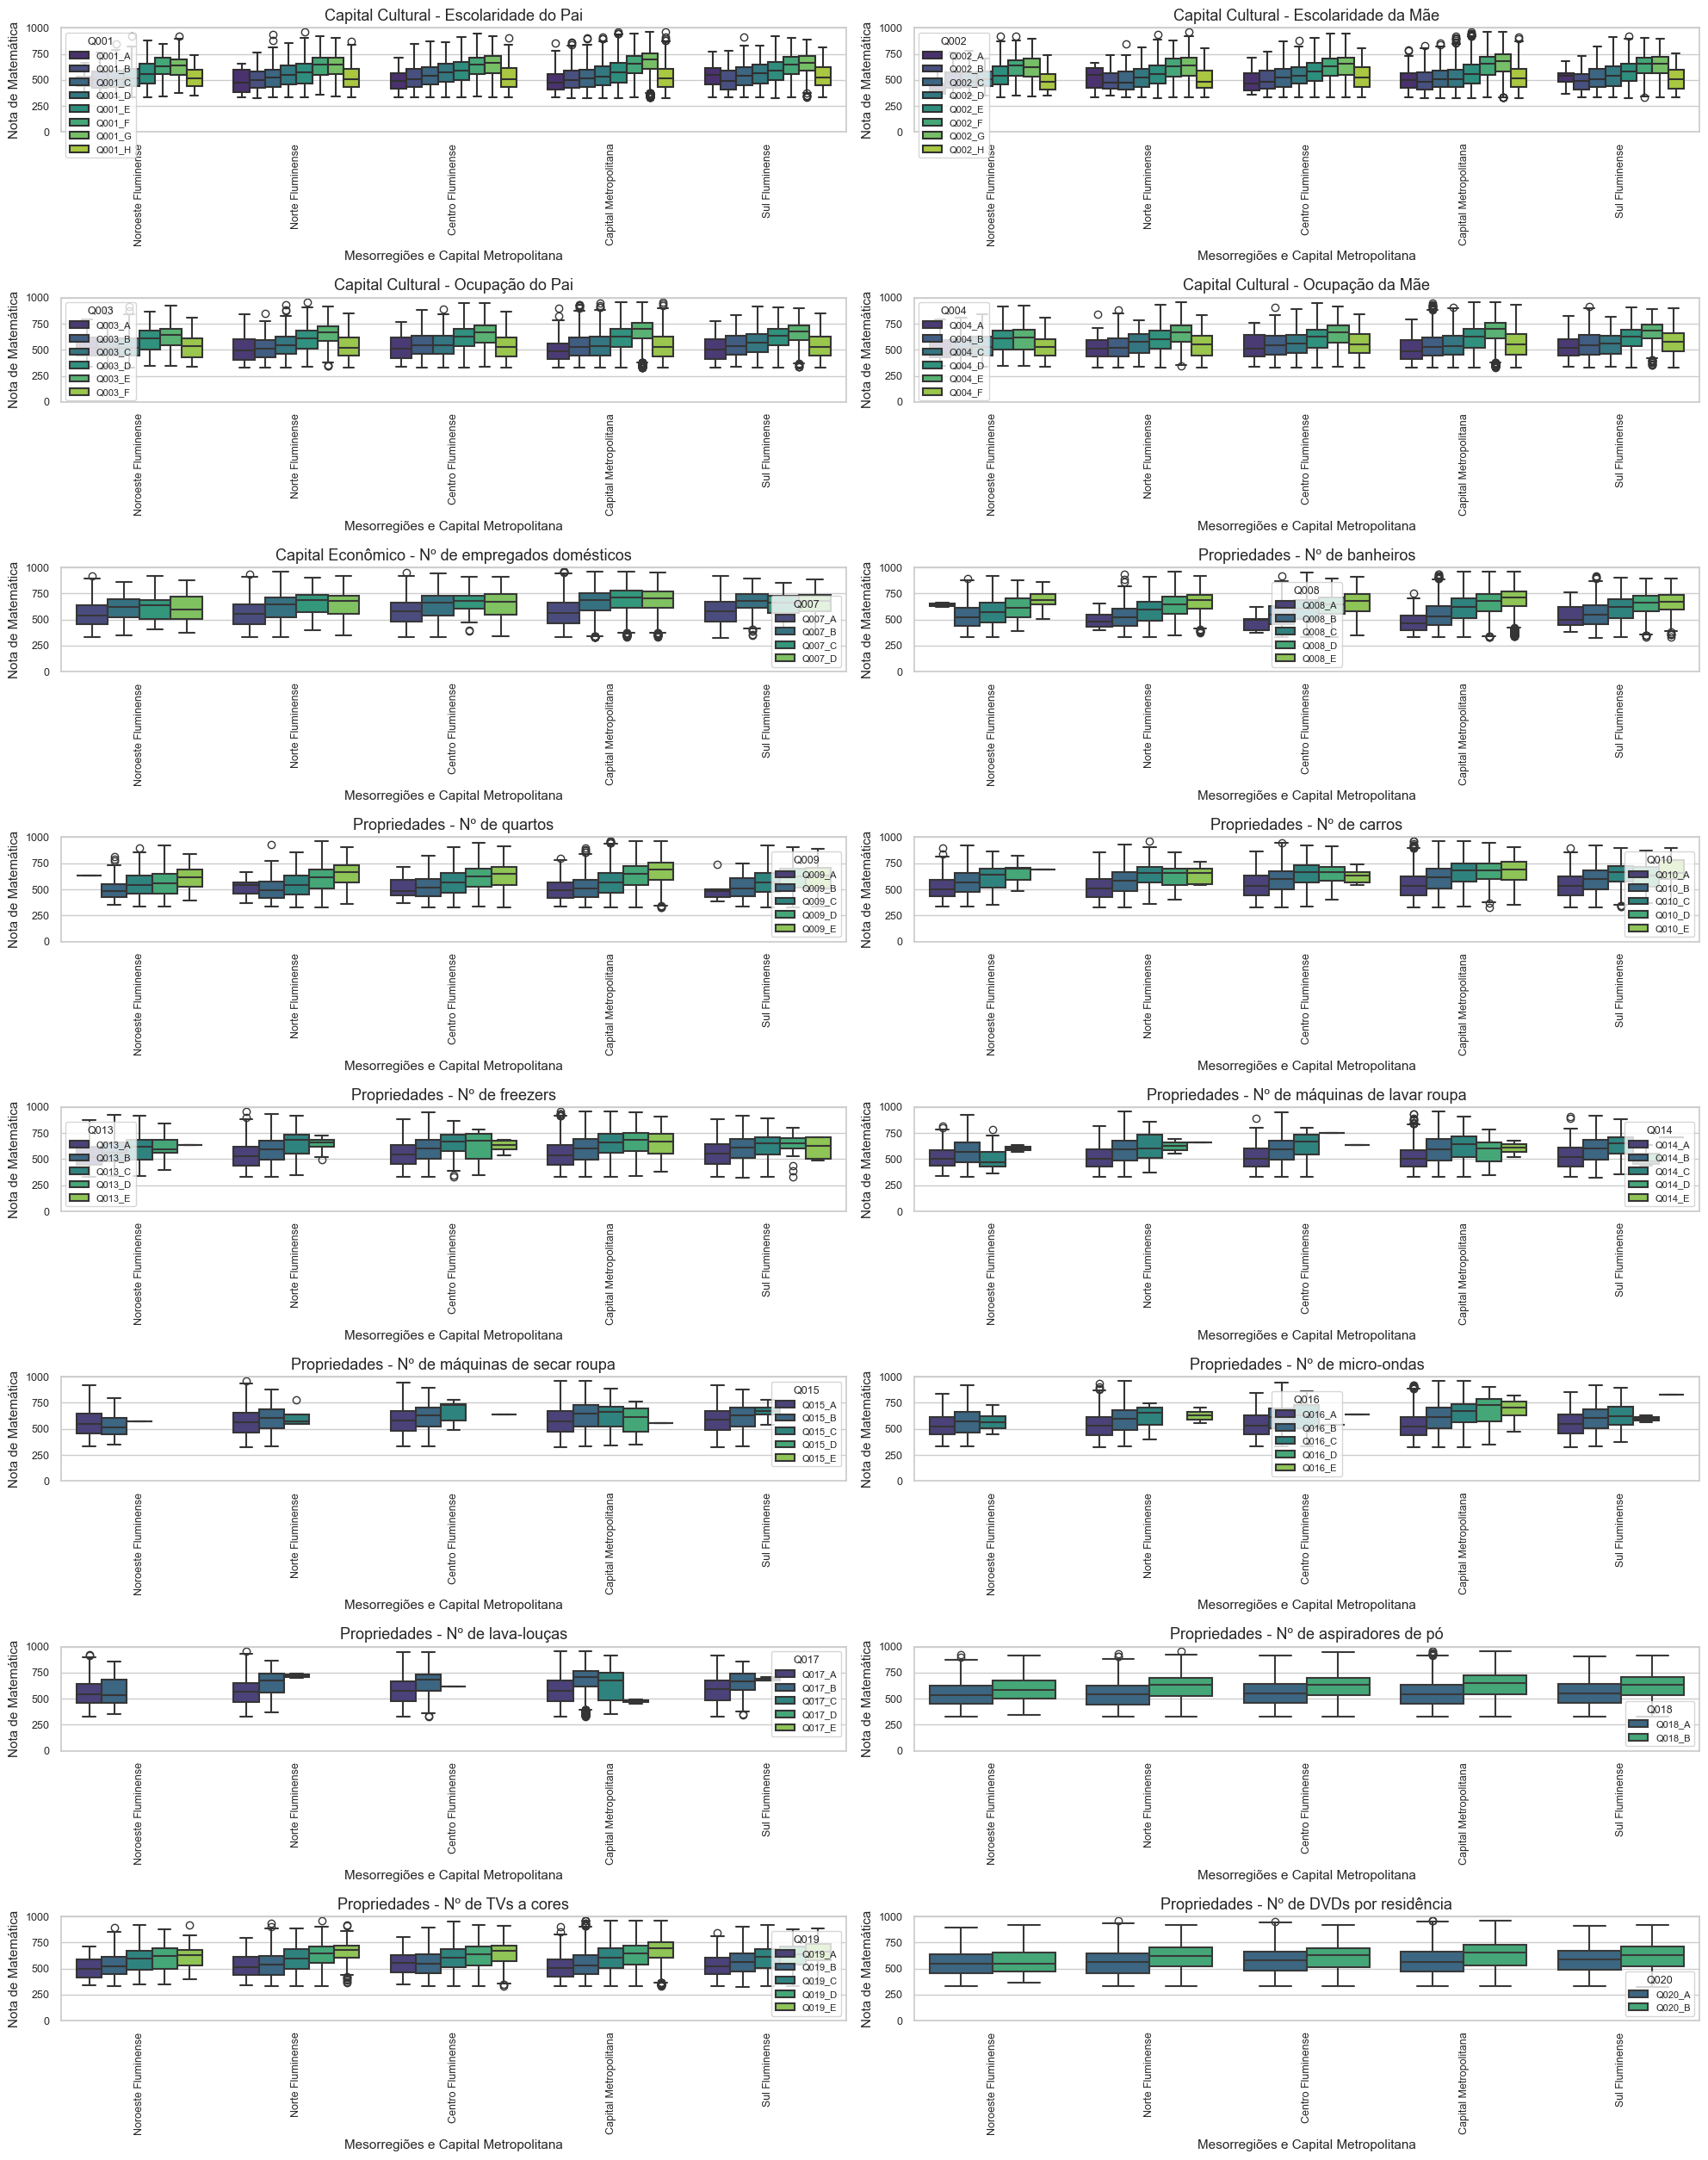

In [236]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# ===== 0) Garantir NU_NOTA_MT numérica (todas as variantes) =====
def smart_to_float(x):
    s = str(x).strip()
    if s == "" or s.lower() in {"nan", "none"}:
        return np.nan
    # "1.234,56" -> remove milhar e troca vírgula por ponto
    if "," in s and "." in s:
        s = s.replace(".", "").replace(",", ".")
    # "365,3" -> vírgula decimal
    elif "," in s:
        s = s.replace(",", ".")
    # "365.3" já ok
    try:
        return float(s)
    except:
        return np.nan

# --- base ---
# df_01 = Educacao_enem_bin_mt_muni_02.copy()  # se precisar
# usa o df_01 que você já tem
df_01["NU_NOTA_MT"] = df_01["NU_NOTA_MT"].apply(smart_to_float)

# Mesorregiao como string/categoria (evita problemas de rótulo)
if "Mesorregiao" in df_01.columns:
    df_01["Mesorregiao"] = df_01["Mesorregiao"].astype(str)

# ===== 1) Função robusta para boxplot + legenda =====
def plot_boxplot(ax, base_df, ordem_categorias, hue_col, title):
    cols = ["Mesorregiao", "NU_NOTA_MT", hue_col]
    missing = [c for c in cols if c not in base_df.columns]
    if missing:
        ax.text(0.5, 0.5, f"Coluna(s) ausente(s): {', '.join(missing)}", ha="center", va="center")
        ax.set_axis_off()
        return

    sub = base_df.loc[:, cols].dropna(subset=["Mesorregiao", "NU_NOTA_MT"]).copy()
    # se o hue tiver muitos NaN, você pode optar por não dropar:
    sub = sub.dropna(subset=[hue_col])

    if sub.empty:
        ax.text(0.5, 0.5, "Sem dados válidos", ha="center", va="center")
        ax.set_axis_off()
        return

    sub["Mesorregiao"] = sub["Mesorregiao"].astype(str)
    sub[hue_col] = sub[hue_col].astype(str)

    # Ordem apenas com categorias presentes (ou use ordem_categorias direto se quiser ver todos os rótulos)
    ordem_local = [c for c in ordem_categorias if c in sub["Mesorregiao"].unique()]
    if not ordem_local:
        ax.text(0.5, 0.5, "Sem categorias na ordem", ha="center", va="center")
        ax.set_axis_off()
        return

    sns.boxplot(
        data=sub,
        x="Mesorregiao",
        y="NU_NOTA_MT",
        order=ordem_local,
        hue=hue_col,
        linewidth=1.5,
        orient="v",
        palette="viridis",
        ax=ax
    )

    ax.set_title(title, fontsize=13)
    ax.set_ylabel("Nota de Matemática", fontsize=11)
    ax.set_xlabel("Mesorregiões e Capital Metropolitana", fontsize=11)
    ax.tick_params(axis="x", rotation=90, labelsize=9)
    ax.tick_params(axis="y", labelsize=9)
    ax.set_ylim(0, 1000)  # escala típica da prova
    ax.legend(title=hue_col, fontsize=8, title_fontsize=9, frameon=True, loc="best")

# ===== 2) Ordem das categorias por mediana (só com dados válidos) =====
base_ordem = df_01.dropna(subset=["Mesorregiao", "NU_NOTA_MT"])
medianas = base_ordem.groupby("Mesorregiao")["NU_NOTA_MT"].median().sort_values()
ordem_categorias = list(medianas.index)

# ===== 3) Helper =====
def sort_for(var):
    return df_01.sort_values(by=["Mesorregiao", var], na_position="last")

# ===== 4) Grid e lista de gráficos =====
plots = [
    ("Q001", "Capital Cultural - Escolaridade do Pai"),
    ("Q002", "Capital Cultural - Escolaridade da Mãe"),
    ("Q003", "Capital Cultural - Ocupação do Pai"),
    ("Q004", "Capital Cultural - Ocupação da Mãe"),
    ("Q007", "Capital Econômico - Nº de empregados domésticos"),
    ("Q008", "Propriedades - Nº de banheiros"),
    ("Q009", "Propriedades - Nº de quartos"),
    ("Q010", "Propriedades - Nº de carros"),
    ("Q013", "Propriedades - Nº de freezers"),
    ("Q014", "Propriedades - Nº de máquinas de lavar roupa"),
    ("Q015", "Propriedades - Nº de máquinas de secar roupa"),
    ("Q016", "Propriedades - Nº de micro-ondas"),
    ("Q017", "Propriedades - Nº de lava-louças"),
    ("Q018", "Propriedades - Nº de aspiradores de pó"),
    ("Q019", "Propriedades - Nº de TVs a cores"),
    ("Q020", "Propriedades - Nº de DVDs por residência"),
]

rows, cols = 10, 2
fig, axs = plt.subplots(rows, cols, figsize=(20, 30))

for i, (hue_col, titulo) in enumerate(plots):
    r, c = divmod(i, cols)
    plot_boxplot(axs[r, c], sort_for(hue_col), ordem_categorias, hue_col, titulo)

# Esconde eixos não usados
flat_axes = axs.flatten()
for ax in flat_axes[len(plots):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

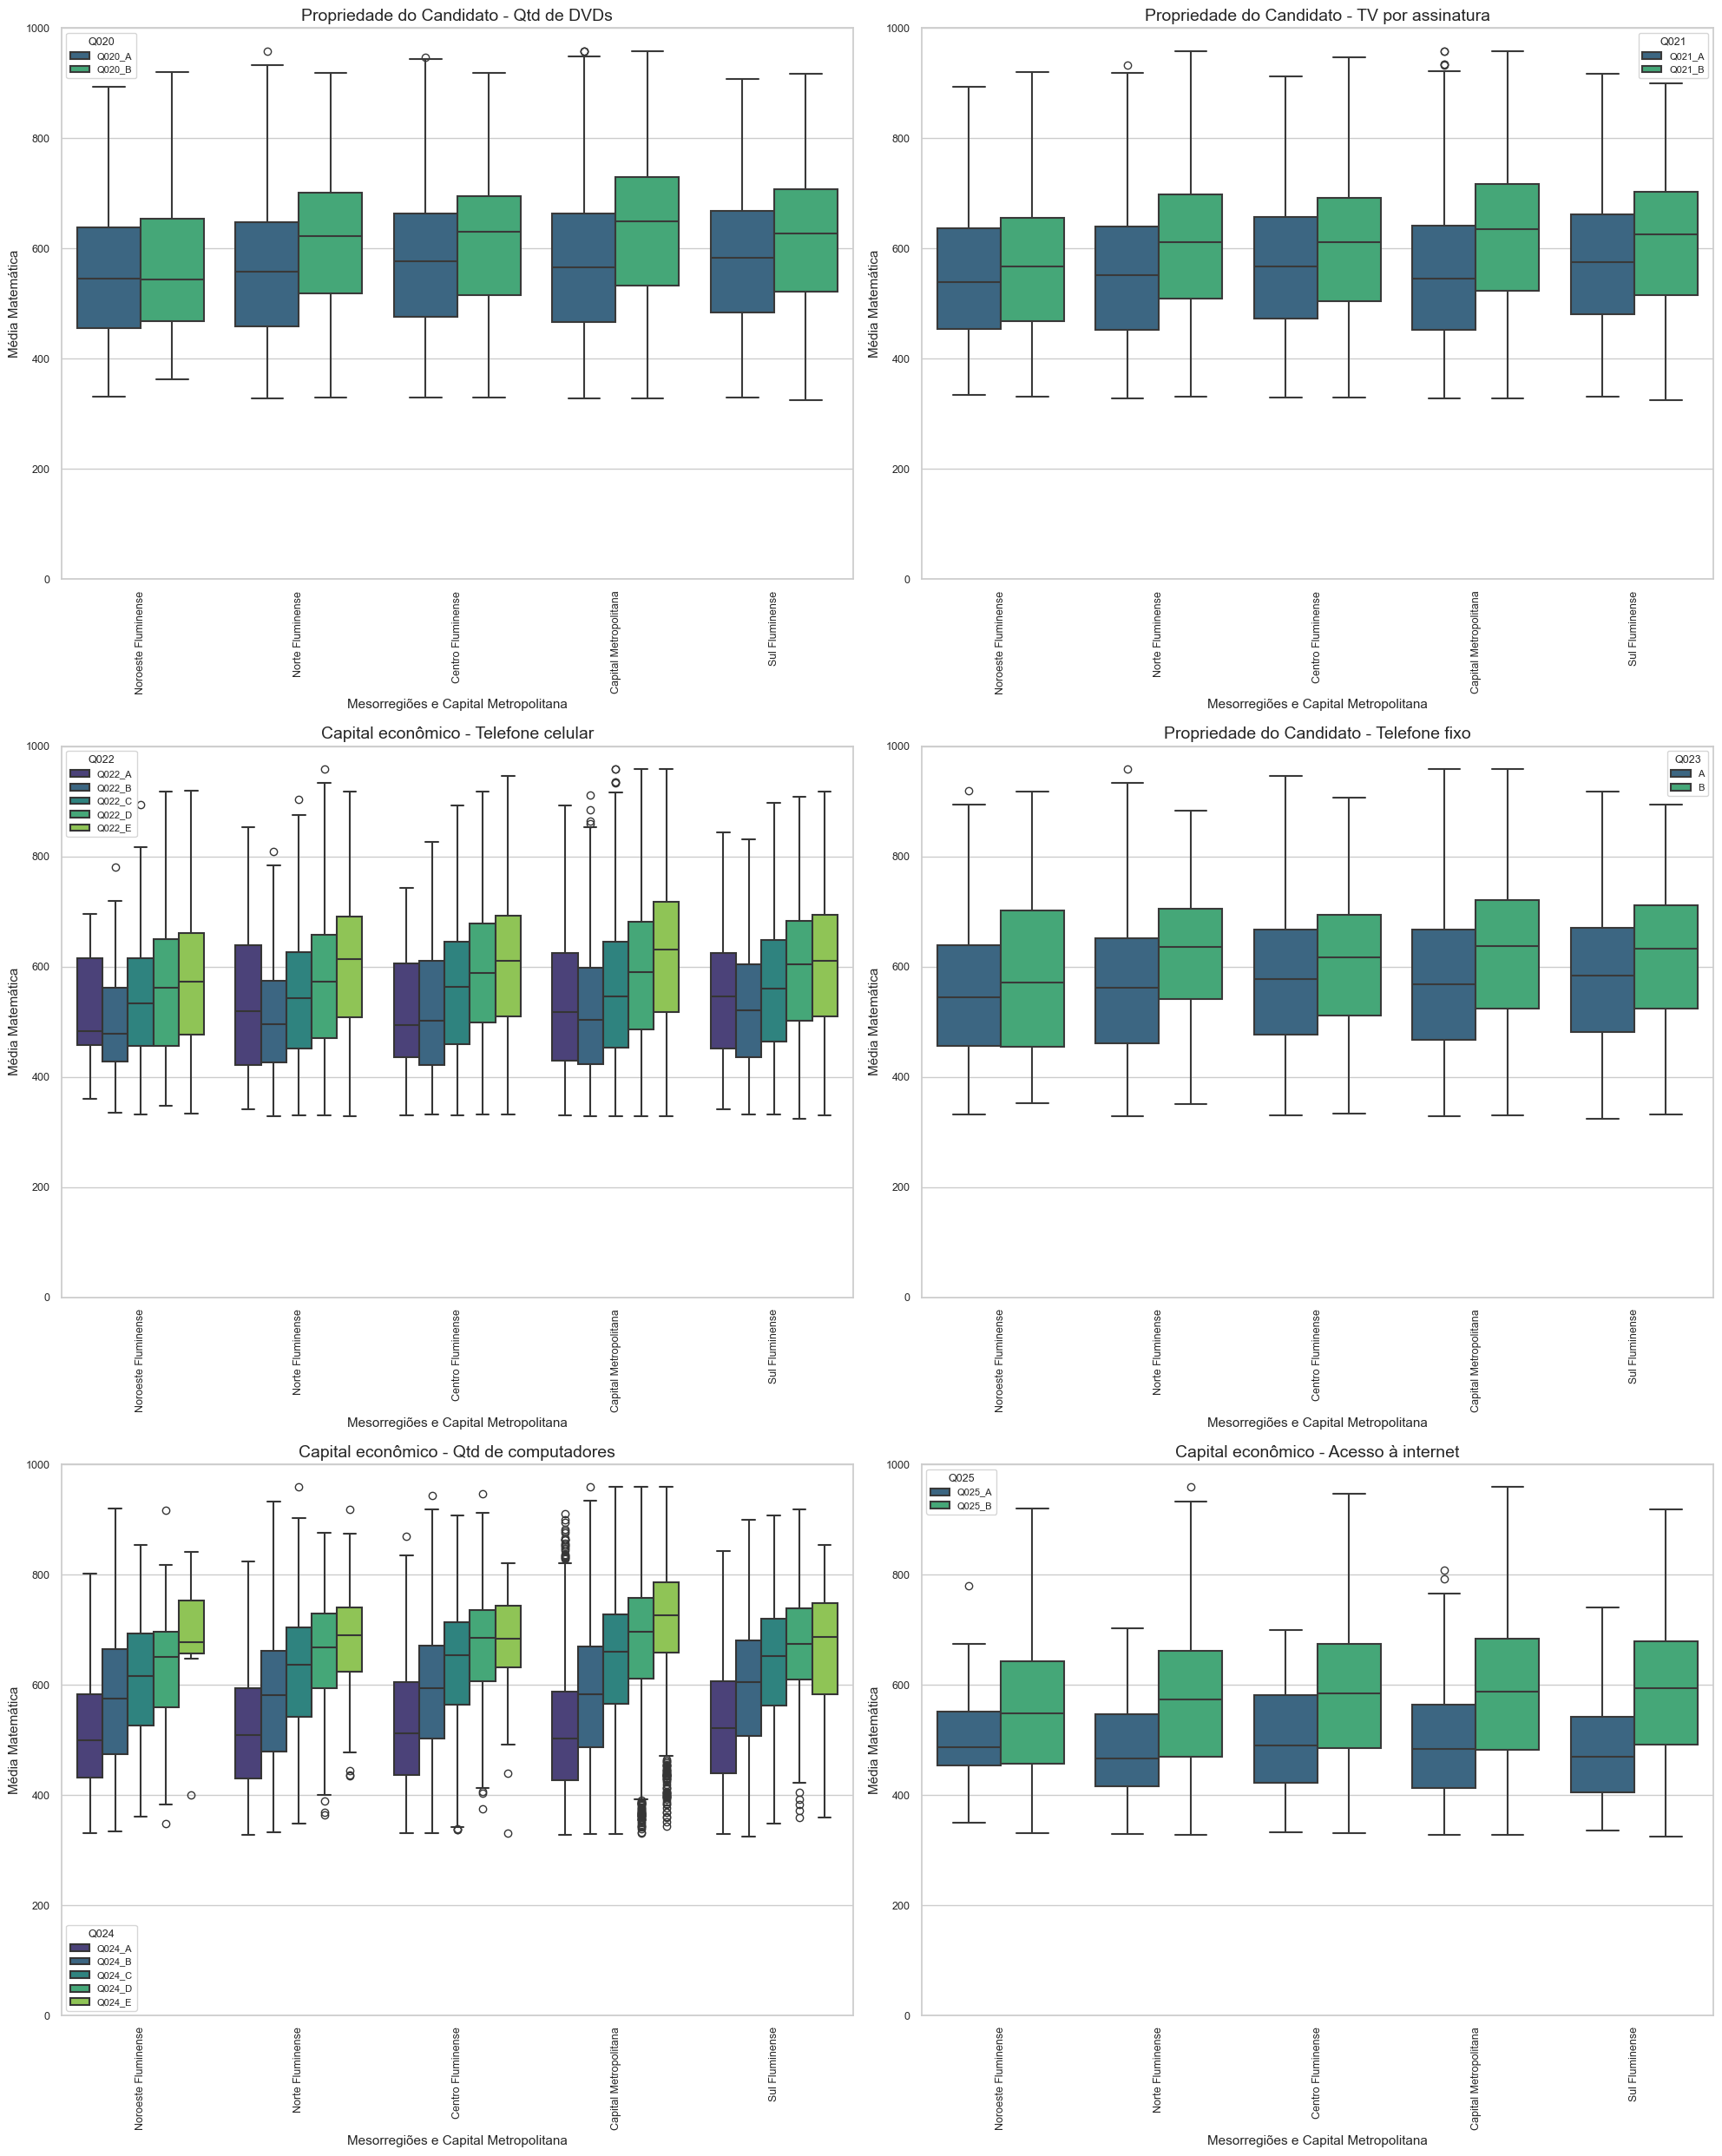

In [237]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# ===== 0) Sanitização: garantir NU_NOTA_MT numérica (lida com 1.234,5 | 365,3 | 365.3) =====
def smart_to_float(x):
    s = str(x).strip()
    if s == "" or s.lower() in {"nan", "none"}:
        return np.nan
    if "," in s and "." in s:          # "1.234,56" -> milhar ".", decimal ","
        s = s.replace(".", "").replace(",", ".")
    elif "," in s:                     # "365,3" -> vírgula decimal
        s = s.replace(",", ".")
    # "365.3" já está ok
    try:
        return float(s)
    except:
        return np.nan

# Converte NU_NOTA_MT no df_01 existente
df_01["NU_NOTA_MT"] = df_01["NU_NOTA_MT"].apply(smart_to_float)

# Mesorregiao como string (evita problemas de rótulo)
if "Mesorregiao" in df_01.columns:
    df_01["Mesorregiao"] = df_01["Mesorregiao"].astype(str)

# ===== 1) Função robusta para boxplot com legenda em cada gráfico =====
def plot_boxplot(ax, base_df, ordem_categorias, hue_col, title):
    cols = ["Mesorregiao", "NU_NOTA_MT", hue_col]
    sub = base_df.loc[:, cols].dropna(subset=["Mesorregiao", "NU_NOTA_MT"]).copy()
    # não derruba tudo se hue tiver alguns NaN; mas se quiser forçar, descomente:
    sub = sub.dropna(subset=[hue_col])

    if sub.empty:
        ax.text(0.5, 0.5, "Sem dados válidos", ha="center", va="center")
        ax.set_axis_off()
        return

    sub["Mesorregiao"] = pd.Categorical(sub["Mesorregiao"],
                                        categories=list(ordem_categorias),
                                        ordered=True)
    sub[hue_col] = sub[hue_col].astype(str)

    sns.boxplot(
        data=sub,
        x="Mesorregiao",
        y="NU_NOTA_MT",
        order=list(ordem_categorias),     # mostra TODAS as mesorregiões no eixo X
        hue=hue_col,
        linewidth=1.5,
        orient='v',
        palette='viridis',
        ax=ax
    )
    ax.set_title(title, fontsize=14)
    ax.set_ylabel('Média Matemática', fontsize=11)
    ax.set_xlabel('Mesorregiões e Capital Metropolitana', fontsize=11)
    ax.tick_params(axis='x', rotation=90, labelsize=9)
    ax.tick_params(axis='y', labelsize=9)
    ax.set_ylim(0, 1000)  # escala típica ENEM
    ax.legend(title=hue_col, fontsize=8, title_fontsize=9, frameon=True, loc="best")

# ===== 2) Subplots layout =====
fig, axs = plt.subplots(3, 2, figsize=(20, 25))
fig.tight_layout(pad=5.0)

# ===== 3) Ordem das categorias por mediana (usando df_01) =====
base_ordem = df_01.dropna(subset=["Mesorregiao", "NU_NOTA_MT"])
medianas = base_ordem.groupby('Mesorregiao')["NU_NOTA_MT"].median().sort_values()
ordem_categorias = list(medianas.index)

# ===== 4) Helper (usa df_01) =====
def sort_for(var):
    return df_01.sort_values(by=['Mesorregiao', var], na_position='last')

# ===== 5) Plots =====
plot_boxplot(axs[0, 0], sort_for('Q020'), ordem_categorias, 'Q020',
             'Propriedade do Candidato - Qtd de DVDs')

plot_boxplot(axs[0, 1], sort_for('Q021'), ordem_categorias, 'Q021',
             'Propriedade do Candidato - TV por assinatura')

plot_boxplot(axs[1, 0], sort_for('Q022'), ordem_categorias, 'Q022',
             'Capital econômico - Telefone celular')

plot_boxplot(axs[1, 1], sort_for('Q023'), ordem_categorias, 'Q023',
             'Propriedade do Candidato - Telefone fixo')

plot_boxplot(axs[2, 0], sort_for('Q024'), ordem_categorias, 'Q024',
             'Capital econômico - Qtd de computadores')

plot_boxplot(axs[2, 1], sort_for('Q025'), ordem_categorias, 'Q025',
             'Capital econômico - Acesso à internet')

plt.tight_layout()
plt.show()

## REDAÇÃO

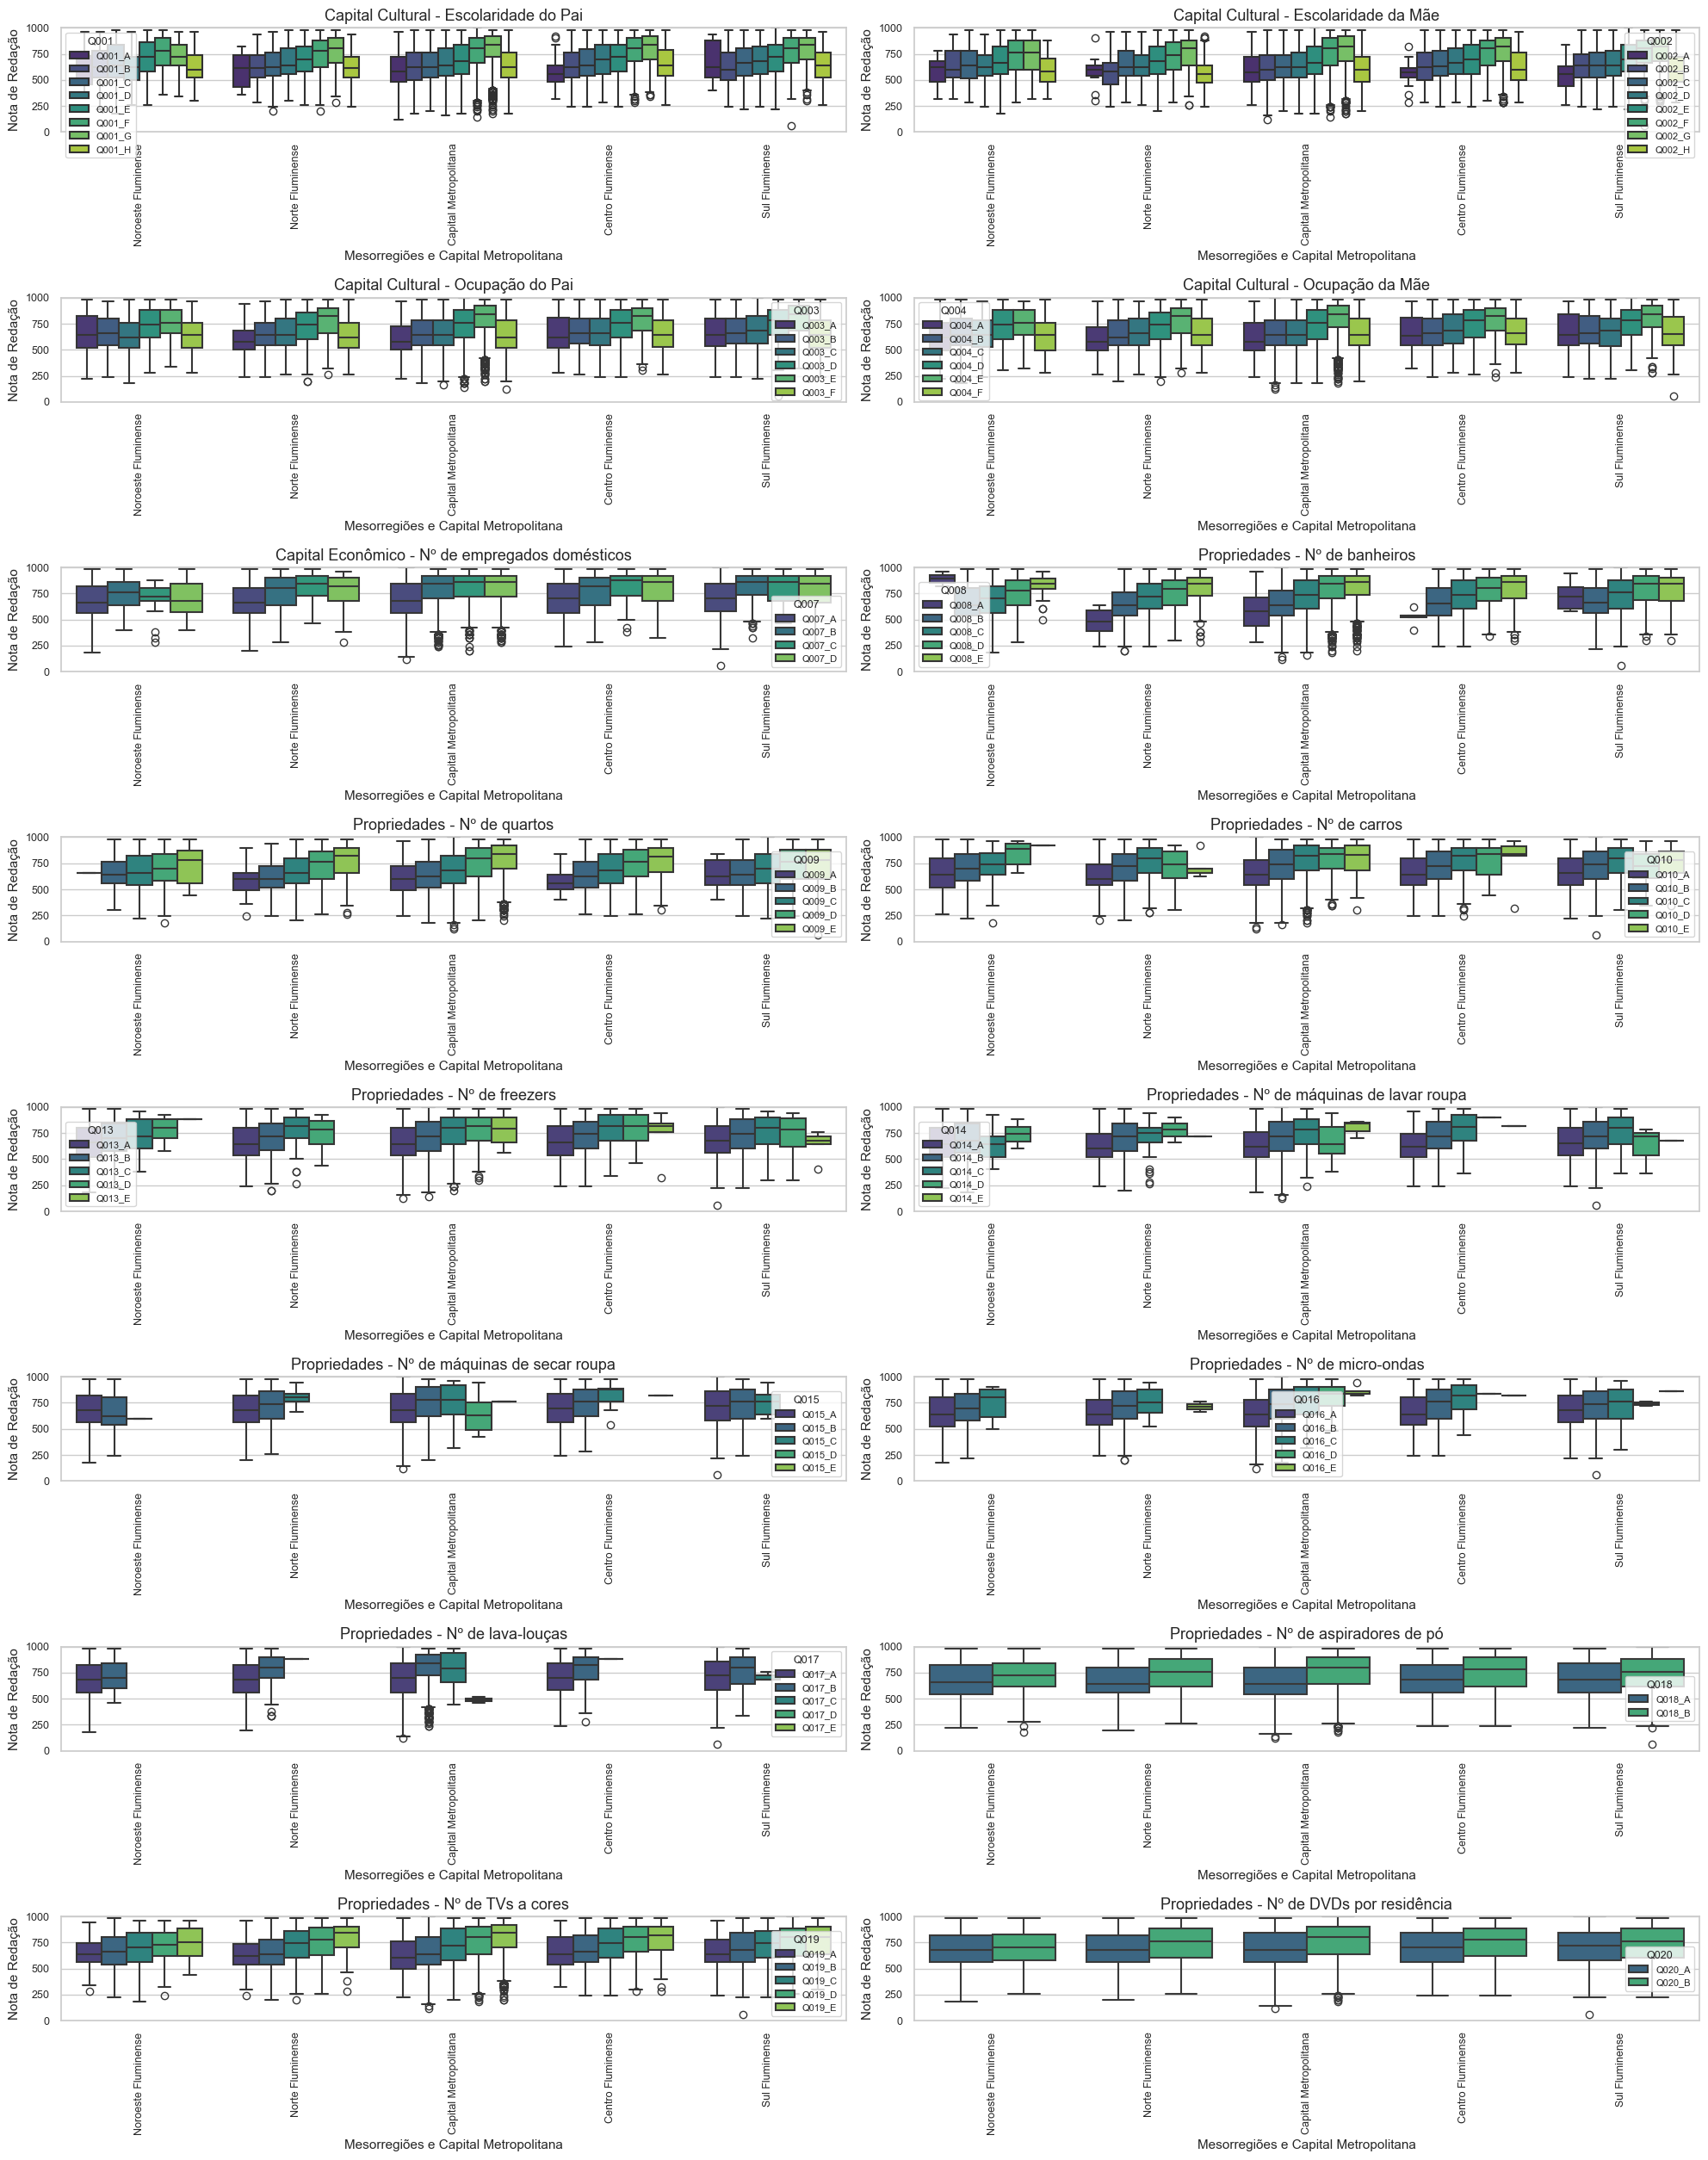

In [238]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# ===== 0) Garantir NU_NOTA_REDACAO numérica (aceita 1.234,5 | 365,3 | 365.3) =====
def smart_to_float(x):
    s = str(x).strip()
    if s == "" or s.lower() in {"nan", "none"}:
        return np.nan
    if "," in s and "." in s:          # "1.234,56" -> milhar ".", decimal ","
        s = s.replace(".", "").replace(",", ".")
    elif "," in s:                     # "365,3" -> vírgula decimal
        s = s.replace(",", ".")
    # "365.3" já ok
    try:
        return float(s)
    except:
        return np.nan

# Converte NU_NOTA_REDACAO
df_01["NU_NOTA_REDACAO"] = df_01["NU_NOTA_REDACAO"].apply(smart_to_float)

# Mesorregiao como string (evita problemas de rótulo)
if "Mesorregiao" in df_01.columns:
    df_01["Mesorregiao"] = df_01["Mesorregiao"].astype(str)

# ===== 1) Função robusta para boxplot + legenda =====
def plot_boxplot(ax, base_df, ordem_categorias, hue_col, title):
    cols = ["Mesorregiao", "NU_NOTA_REDACAO", hue_col]
    missing = [c for c in cols if c not in base_df.columns]
    if missing:
        ax.text(0.5, 0.5, f"Coluna(s) ausente(s): {', '.join(missing)}", ha="center", va="center")
        ax.set_axis_off()
        return

    sub = base_df.loc[:, cols].dropna(subset=["Mesorregiao", "NU_NOTA_REDACAO"]).copy()
    # Se preferir não derrubar por hue NaN, comente a linha abaixo
    sub = sub.dropna(subset=[hue_col])

    if sub.empty:
        ax.text(0.5, 0.5, "Sem dados válidos", ha="center", va="center")
        ax.set_axis_off()
        return

    # Garantir TODAS as mesorregiões no eixo X (mesmo sem dado para algum hue)
    sub["Mesorregiao"] = pd.Categorical(sub["Mesorregiao"],
                                        categories=list(ordem_categorias),
                                        ordered=True)
    sub[hue_col] = sub[hue_col].astype(str)

    sns.boxplot(
        data=sub,
        x="Mesorregiao",
        y="NU_NOTA_REDACAO",
        order=list(ordem_categorias),
        hue=hue_col,
        linewidth=1.5,
        orient="v",
        palette="viridis",
        ax=ax
    )

    ax.set_title(title, fontsize=13)
    ax.set_ylabel("Nota de Redação", fontsize=11)
    ax.set_xlabel("Mesorregiões e Capital Metropolitana", fontsize=11)
    ax.tick_params(axis="x", rotation=90, labelsize=9)
    ax.tick_params(axis="y", labelsize=9)
    ax.set_ylim(0, 1000)  # escala típica da redação
    ax.legend(title=hue_col, fontsize=8, title_fontsize=9, frameon=True, loc="best")

# ===== 2) Ordem das categorias por mediana (só com dados válidos) =====
base_ordem = df_01.dropna(subset=["Mesorregiao", "NU_NOTA_REDACAO"])
medianas = base_ordem.groupby("Mesorregiao")["NU_NOTA_REDACAO"].median().sort_values()
ordem_categorias = list(medianas.index)

# ===== 3) Helper (usa df_01, não df) =====
def sort_for(var):
    return df_01.sort_values(by=["Mesorregiao", var], na_position="last")

# ===== 4) Grid e lista de gráficos =====
plots = [
    ("Q001", "Capital Cultural - Escolaridade do Pai"),
    ("Q002", "Capital Cultural - Escolaridade da Mãe"),
    ("Q003", "Capital Cultural - Ocupação do Pai"),
    ("Q004", "Capital Cultural - Ocupação da Mãe"),

    ("Q007", "Capital Econômico - Nº de empregados domésticos"),
    ("Q008", "Propriedades - Nº de banheiros"),
    ("Q009", "Propriedades - Nº de quartos"),
    ("Q010", "Propriedades - Nº de carros"),

    ("Q013", "Propriedades - Nº de freezers"),
    ("Q014", "Propriedades - Nº de máquinas de lavar roupa"),
    ("Q015", "Propriedades - Nº de máquinas de secar roupa"),
    ("Q016", "Propriedades - Nº de micro-ondas"),

    ("Q017", "Propriedades - Nº de lava-louças"),
    ("Q018", "Propriedades - Nº de aspiradores de pó"),
    ("Q019", "Propriedades - Nº de TVs a cores"),
    ("Q020", "Propriedades - Nº de DVDs por residência"),
]

rows, cols = 10, 2
fig, axs = plt.subplots(rows, cols, figsize=(20, 30))

for i, (hue_col, titulo) in enumerate(plots):
    r, c = divmod(i, cols)
    plot_boxplot(axs[r, c], sort_for(hue_col), ordem_categorias, hue_col, titulo)

# Esconde eixos não usados (você tem 16 gráficos)
flat_axes = axs.flatten()
for ax in flat_axes[len(plots):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

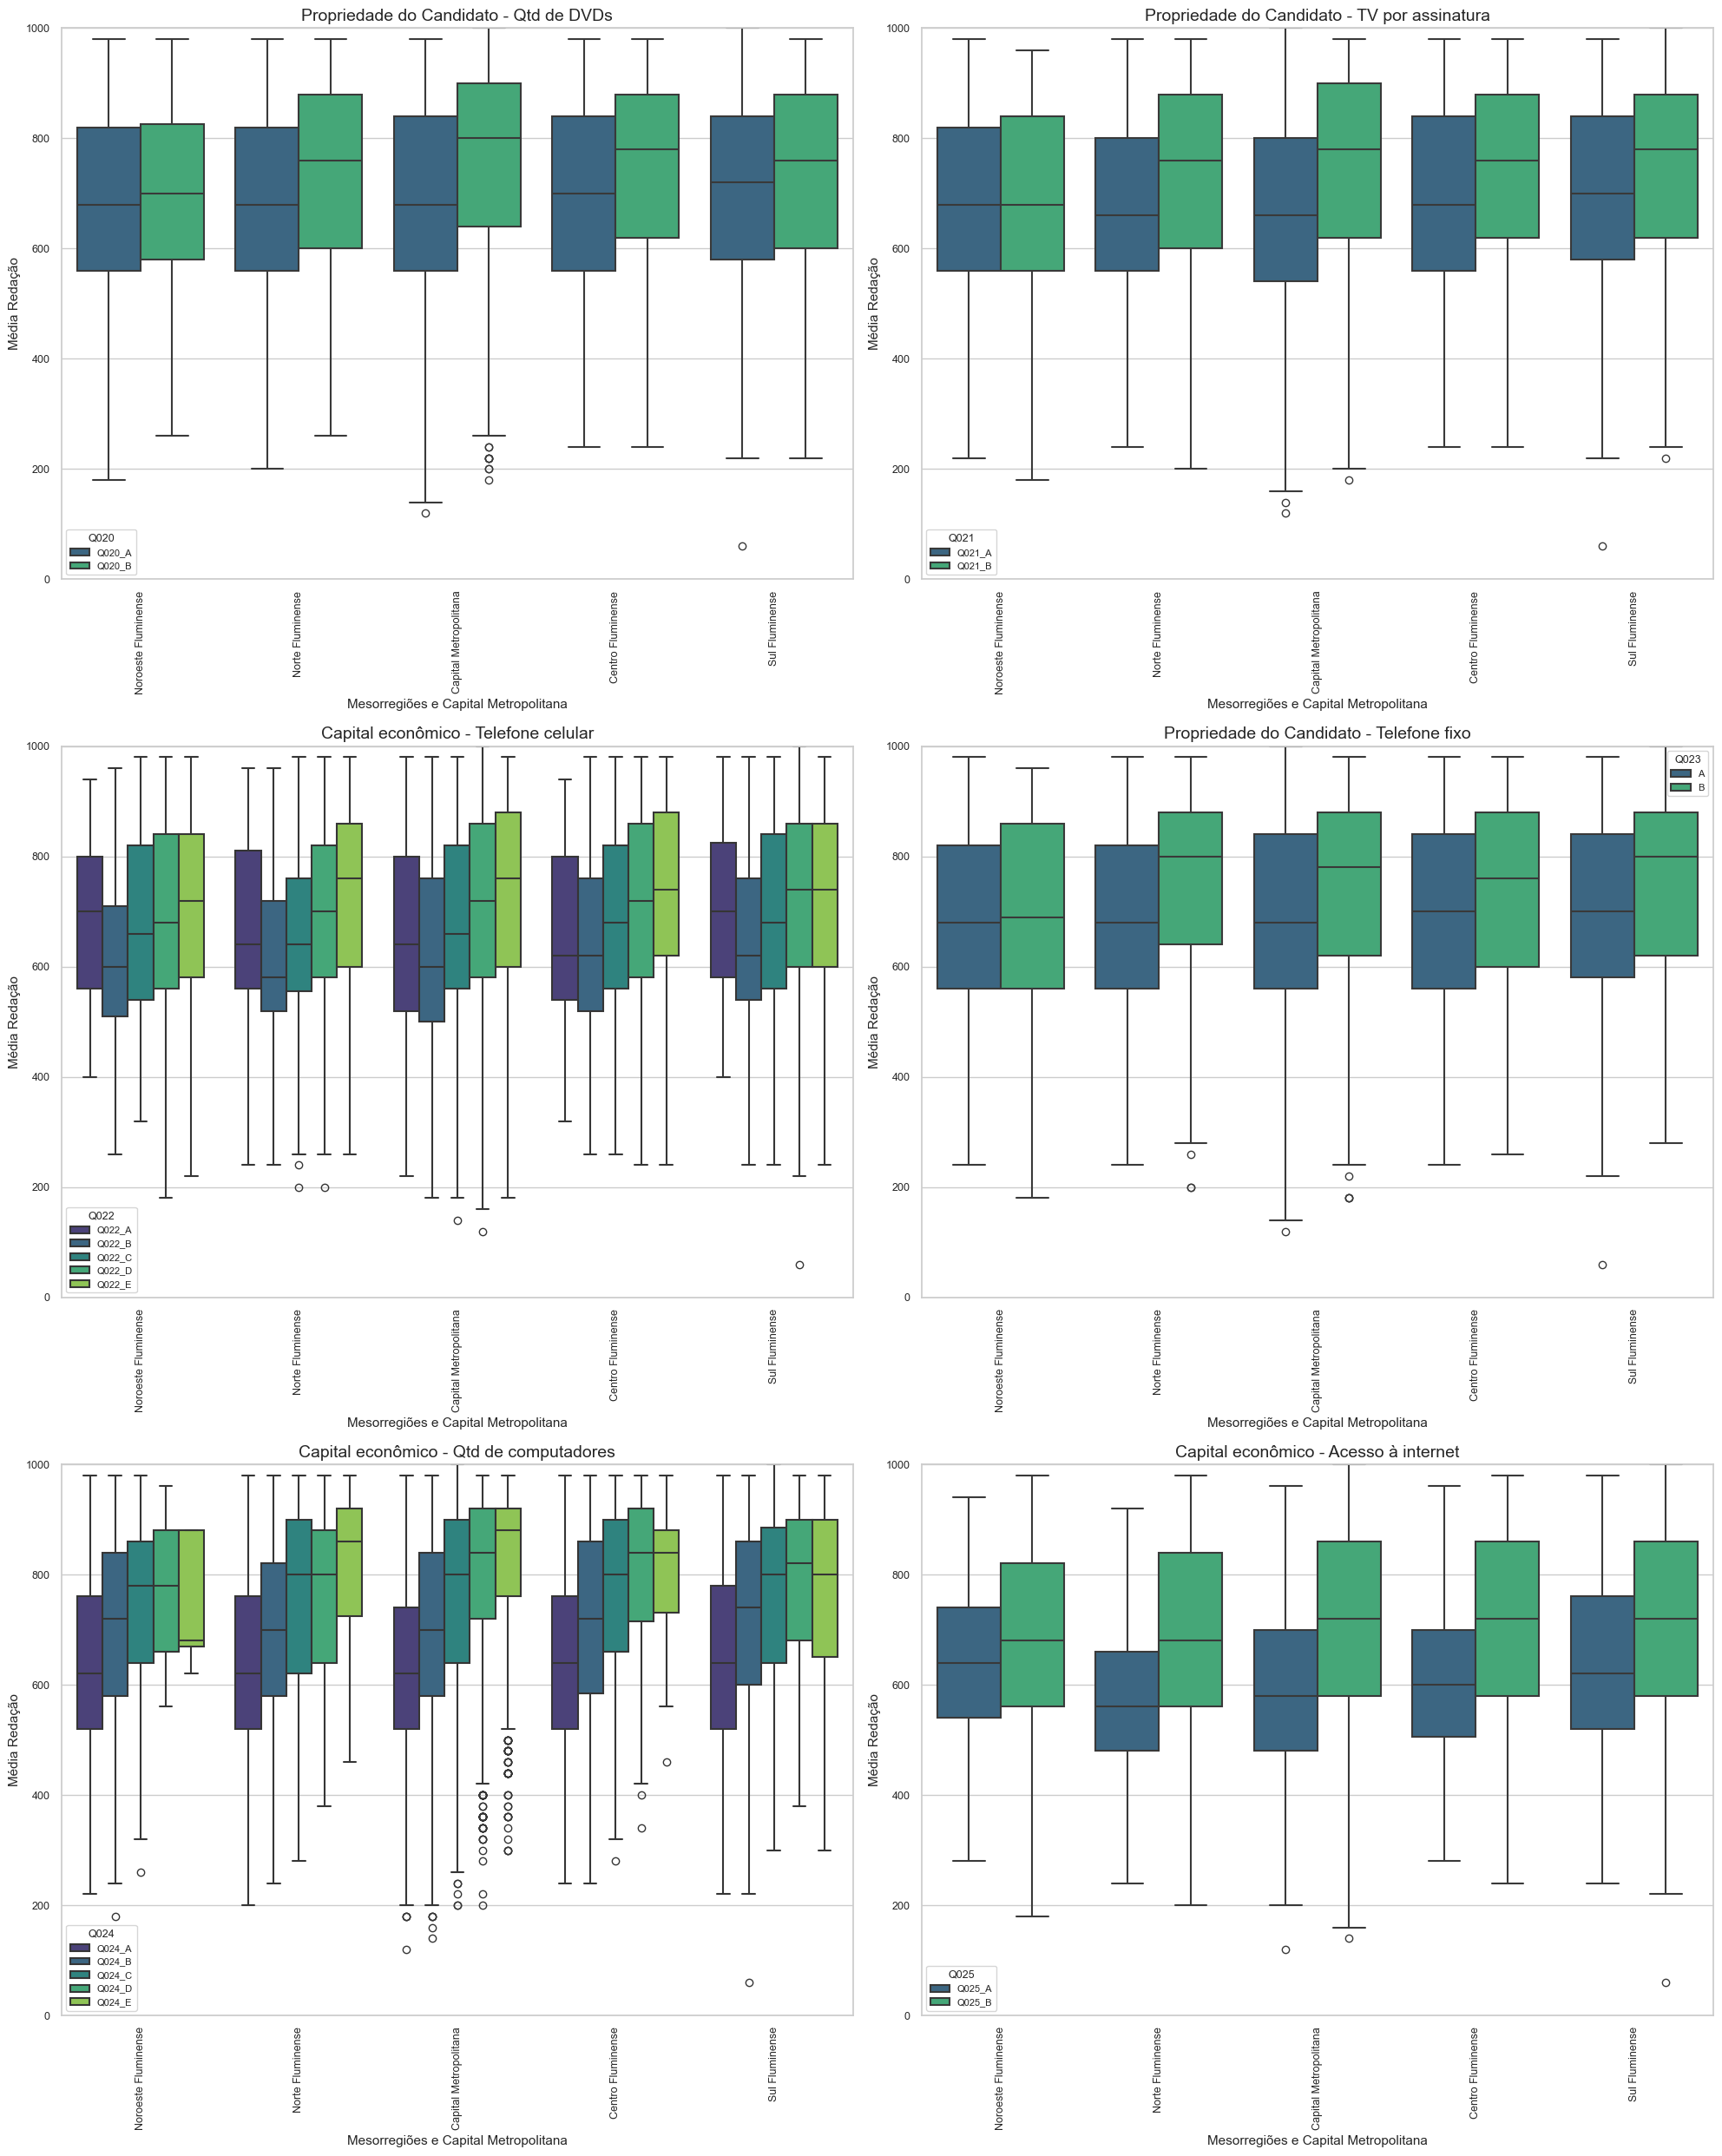

In [240]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# ===== 0) Converter NU_NOTA_REDACAO para float (aceita 1.234,5 | 365,3 | 365.3) =====
def smart_to_float(x):
    s = str(x).strip()
    if s == "" or s.lower() in {"nan", "none"}:
        return np.nan
    if "," in s and "." in s:          # "1.234,56" -> milhar ".", decimal ","
        s = s.replace(".", "").replace(",", ".")
    elif "," in s:                     # "365,3" -> vírgula decimal
        s = s.replace(",", ".")
    try:
        return float(s)
    except:
        return np.nan

# Converte
df_01["NU_NOTA_REDACAO"] = df_01["NU_NOTA_REDACAO"].apply(smart_to_float)

# Mesorregiao como string
if "Mesorregiao" in df_01.columns:
    df_01["Mesorregiao"] = df_01["Mesorregiao"].astype(str)

# ===== 1) Função robusta de boxplot =====
def plot_boxplot(ax, base_df, ordem_categorias, hue_col, title):
    cols = ["Mesorregiao", "NU_NOTA_REDACAO", hue_col]
    sub = base_df.loc[:, cols].dropna(subset=["Mesorregiao", "NU_NOTA_REDACAO"]).copy()
    # Se quiser manter linhas mesmo com hue NaN, comente a linha abaixo:
    sub = sub.dropna(subset=[hue_col])

    if sub.empty:
        ax.text(0.5, 0.5, "Sem dados válidos", ha="center", va="center"); ax.set_axis_off(); return

    # Garante TODAS as mesorregiões no eixo X
    sub["Mesorregiao"] = pd.Categorical(sub["Mesorregiao"],
                                        categories=list(ordem_categorias),
                                        ordered=True)
    sub[hue_col] = sub[hue_col].astype(str)

    sns.boxplot(
        data=sub,
        x="Mesorregiao",
        y="NU_NOTA_REDACAO",
        order=list(ordem_categorias),
        hue=hue_col,
        linewidth=1.5,
        orient='v',
        palette='viridis',
        ax=ax
    )
    ax.set_title(title, fontsize=14)
    ax.set_ylabel('Média Redação', fontsize=11)
    ax.set_xlabel('Mesorregiões e Capital Metropolitana', fontsize=11)
    ax.tick_params(axis='x', rotation=90, labelsize=9)
    ax.tick_params(axis='y', labelsize=9)
    ax.set_ylim(0, 1000)
    ax.legend(title=hue_col, fontsize=8, title_fontsize=9, frameon=True, loc="best")

# ===== 2) Subplots layout =====
fig, axs = plt.subplots(3, 2, figsize=(20, 25))
fig.tight_layout(pad=5.0)

# ===== 3) Ordem das categorias por mediana (usando df_01) =====
base_ordem = df_01.dropna(subset=["Mesorregiao", "NU_NOTA_REDACAO"])
medianas = base_ordem.groupby('Mesorregiao')["NU_NOTA_REDACAO"].median().sort_values()
ordem_categorias = list(medianas.index)

# ===== 4) Helper (usa df_01) =====
def sort_for(var):
    return df_01.sort_values(by=['Mesorregiao', var], na_position='last')

# ===== 5) Plots =====
plot_boxplot(axs[0, 0], sort_for('Q020'), ordem_categorias, 'Q020',
             'Propriedade do Candidato - Qtd de DVDs')

plot_boxplot(axs[0, 1], sort_for('Q021'), ordem_categorias, 'Q021',
             'Propriedade do Candidato - TV por assinatura')

plot_boxplot(axs[1, 0], sort_for('Q022'), ordem_categorias, 'Q022',
             'Capital econômico - Telefone celular')

plot_boxplot(axs[1, 1], sort_for('Q023'), ordem_categorias, 'Q023',
             'Propriedade do Candidato - Telefone fixo')

plot_boxplot(axs[2, 0], sort_for('Q024'), ordem_categorias, 'Q024',
             'Capital econômico - Qtd de computadores')

plot_boxplot(axs[2, 1], sort_for('Q025'), ordem_categorias, 'Q025',
             'Capital econômico - Acesso à internet')

plt.tight_layout()
plt.show()

#### Retirando opções de não respondeu para não afetar modelo final: Divisão entre Metropolitana e Mesorregiões para instituições e estabelecimentos públicos e privados

In [255]:
## Retirando opção não respondeu: capital
Educacao_enem_bin_mt_muni_02_RJ = df_01[df_01['TP_ESCOLA'] != 'Naorespondeu']
Educacao_enem_bin_mt_muni_02_RJ = df_01[df_01['Mesorregiao'] == 'Capital Metropolitana']
Educacao_enem_bin_mt_muni_02_RJ

,NU_INSCRICAO,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,...,TP_SEXO,TP_DEPENDENCIA_ADM_ESC,NO_MUNICIPIO_PROVA,NU_NOTA_MT,NU_NOTA_REDACAO,Q005_z,TP_FAIXA_ETARIA_z,Mesorregiao,NO_MUNICIPIO_PROVA_N,NO_MUNICIPIO_PROVA_PAD
1,210059974463,Q001_B,Q002_D,Q003_C,Q004_B,Q005_4,Q006_B,Q007_A,Q008_B,Q009_C,...,F,ESTADUAL,Rio de Janeiro,365.3,680.0,0.151517,-0.311344,Capital Metropolitana,,RIO DE JANEIRO
2,210058387339,Q001_B,Q002_D,Q003_B,Q004_D,Q005_1,Q006_B,Q007_A,Q008_B,Q009_B,...,M,FEDERAL,Rio de Janeiro,636.8,820.0,-2.048422,1.066768,Capital Metropolitana,,RIO DE JANEIRO
4,210059855138,Q001_B,Q002_D,Q003_C,Q004_B,Q005_4,Q006_A,Q007_B,Q008_B,Q009_B,...,F,ESTADUAL,Rio de Janeiro,396.7,480.0,0.151517,-0.311344,Capital Metropolitana,,RIO DE JANEIRO
5,210059897897,Q001_H,Q002_E,Q003_C,Q004_B,Q005_3,Q006_C,Q007_A,Q008_B,Q009_C,...,F,ESTADUAL,Rio de Janeiro,364.3,840.0,-0.581796,-0.770714,Capital Metropolitana,,RIO DE JANEIRO
6,210058387357,Q001_E,Q002_G,Q003_F,Q004_D,Q005_3,Q006_D,Q007_A,Q008_B,Q009_B,...,F,PRIVADA,Rio de Janeiro,491.5,740.0,-0.581796,-0.311344,Capital Metropolitana,,RIO DE JANEIRO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45082,210059387403,Q001_E,Q002_G,Q003_D,Q004_E,Q005_4,Q006_O,Q007_A,Q008_D,Q009_D,...,M,PRIVADA,Rio de Janeiro,792.2,640.0,0.151517,-0.770714,Capital Metropolitana,,RIO DE JANEIRO
45083,210059477597,Q001_E,Q002_F,Q003_D,Q004_D,Q005_4,Q006_E,Q007_A,Q008_B,Q009_C,...,M,ESTADUAL,Rio de Janeiro,669.2,520.0,0.151517,-0.311344,Capital Metropolitana,,RIO DE JANEIRO
45085,210059634615,Q001_E,Q002_E,Q003_C,Q004_F,Q005_3,Q006_F,Q007_A,Q008_B,Q009_C,...,F,PRIVADA,Rio de Janeiro,828.7,740.0,-0.581796,-0.770714,Capital Metropolitana,,RIO DE JANEIRO
45086,210061345765,Q001_E,Q002_E,Q003_F,Q004_D,Q005_3,Q006_C,Q007_A,Q008_B,Q009_C,...,F,ESTADUAL,São João de Meriti,455.5,760.0,-0.581796,-0.770714,Capital Metropolitana,,SAO JOAO DE MERITI


## MATEMÁTICA

In [256]:
## Contagem das variáveis de exploração, vinculadas a testes estatísticos e que fizeram parte dos preditores finais 
import pandas as pd

# Supondo que 'Educacao_enem_bin_mt_muni_02_RJ' já esteja carregado como um DataFrame
def contar_categorias(df_01, colunas):
    for coluna in colunas:
        print(f"Contagem para a variável {coluna}:")
        print(df_01[coluna].value_counts())
        print("\n")  # Linha em branco para separar os resultados

# Lista das variáveis que você quer contar
variaveis = [
    'TP_SEXO', 'TP_COR_RACA', 'TP_ESCOLA' 
]

# Chamando a função para contar as categorias
contar_categorias(Educacao_enem_bin_mt_muni_02_RJ, variaveis)
Educacao_enem_bin_mt_muni_02_RJ

Contagem para a variável TP_SEXO:
TP_SEXO
F    19187
M    14571
Name: count, dtype: int64


Contagem para a variável TP_COR_RACA:
TP_COR_RACA
BRANCA     18639
PARDA      10046
PRETA       4726
AMARELA      284
Name: count, dtype: int64


Contagem para a variável TP_ESCOLA:
TP_ESCOLA
COLEGIO_PUBLICO    17319
COLEGIO_PRIVADO    16439
Name: count, dtype: int64




,NU_INSCRICAO,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,...,TP_SEXO,TP_DEPENDENCIA_ADM_ESC,NO_MUNICIPIO_PROVA,NU_NOTA_MT,NU_NOTA_REDACAO,Q005_z,TP_FAIXA_ETARIA_z,Mesorregiao,NO_MUNICIPIO_PROVA_N,NO_MUNICIPIO_PROVA_PAD
1,210059974463,Q001_B,Q002_D,Q003_C,Q004_B,Q005_4,Q006_B,Q007_A,Q008_B,Q009_C,...,F,ESTADUAL,Rio de Janeiro,365.3,680.0,0.151517,-0.311344,Capital Metropolitana,,RIO DE JANEIRO
2,210058387339,Q001_B,Q002_D,Q003_B,Q004_D,Q005_1,Q006_B,Q007_A,Q008_B,Q009_B,...,M,FEDERAL,Rio de Janeiro,636.8,820.0,-2.048422,1.066768,Capital Metropolitana,,RIO DE JANEIRO
4,210059855138,Q001_B,Q002_D,Q003_C,Q004_B,Q005_4,Q006_A,Q007_B,Q008_B,Q009_B,...,F,ESTADUAL,Rio de Janeiro,396.7,480.0,0.151517,-0.311344,Capital Metropolitana,,RIO DE JANEIRO
5,210059897897,Q001_H,Q002_E,Q003_C,Q004_B,Q005_3,Q006_C,Q007_A,Q008_B,Q009_C,...,F,ESTADUAL,Rio de Janeiro,364.3,840.0,-0.581796,-0.770714,Capital Metropolitana,,RIO DE JANEIRO
6,210058387357,Q001_E,Q002_G,Q003_F,Q004_D,Q005_3,Q006_D,Q007_A,Q008_B,Q009_B,...,F,PRIVADA,Rio de Janeiro,491.5,740.0,-0.581796,-0.311344,Capital Metropolitana,,RIO DE JANEIRO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45082,210059387403,Q001_E,Q002_G,Q003_D,Q004_E,Q005_4,Q006_O,Q007_A,Q008_D,Q009_D,...,M,PRIVADA,Rio de Janeiro,792.2,640.0,0.151517,-0.770714,Capital Metropolitana,,RIO DE JANEIRO
45083,210059477597,Q001_E,Q002_F,Q003_D,Q004_D,Q005_4,Q006_E,Q007_A,Q008_B,Q009_C,...,M,ESTADUAL,Rio de Janeiro,669.2,520.0,0.151517,-0.311344,Capital Metropolitana,,RIO DE JANEIRO
45085,210059634615,Q001_E,Q002_E,Q003_C,Q004_F,Q005_3,Q006_F,Q007_A,Q008_B,Q009_C,...,F,PRIVADA,Rio de Janeiro,828.7,740.0,-0.581796,-0.770714,Capital Metropolitana,,RIO DE JANEIRO
45086,210061345765,Q001_E,Q002_E,Q003_F,Q004_D,Q005_3,Q006_C,Q007_A,Q008_B,Q009_C,...,F,ESTADUAL,São João de Meriti,455.5,760.0,-0.581796,-0.770714,Capital Metropolitana,,SAO JOAO DE MERITI


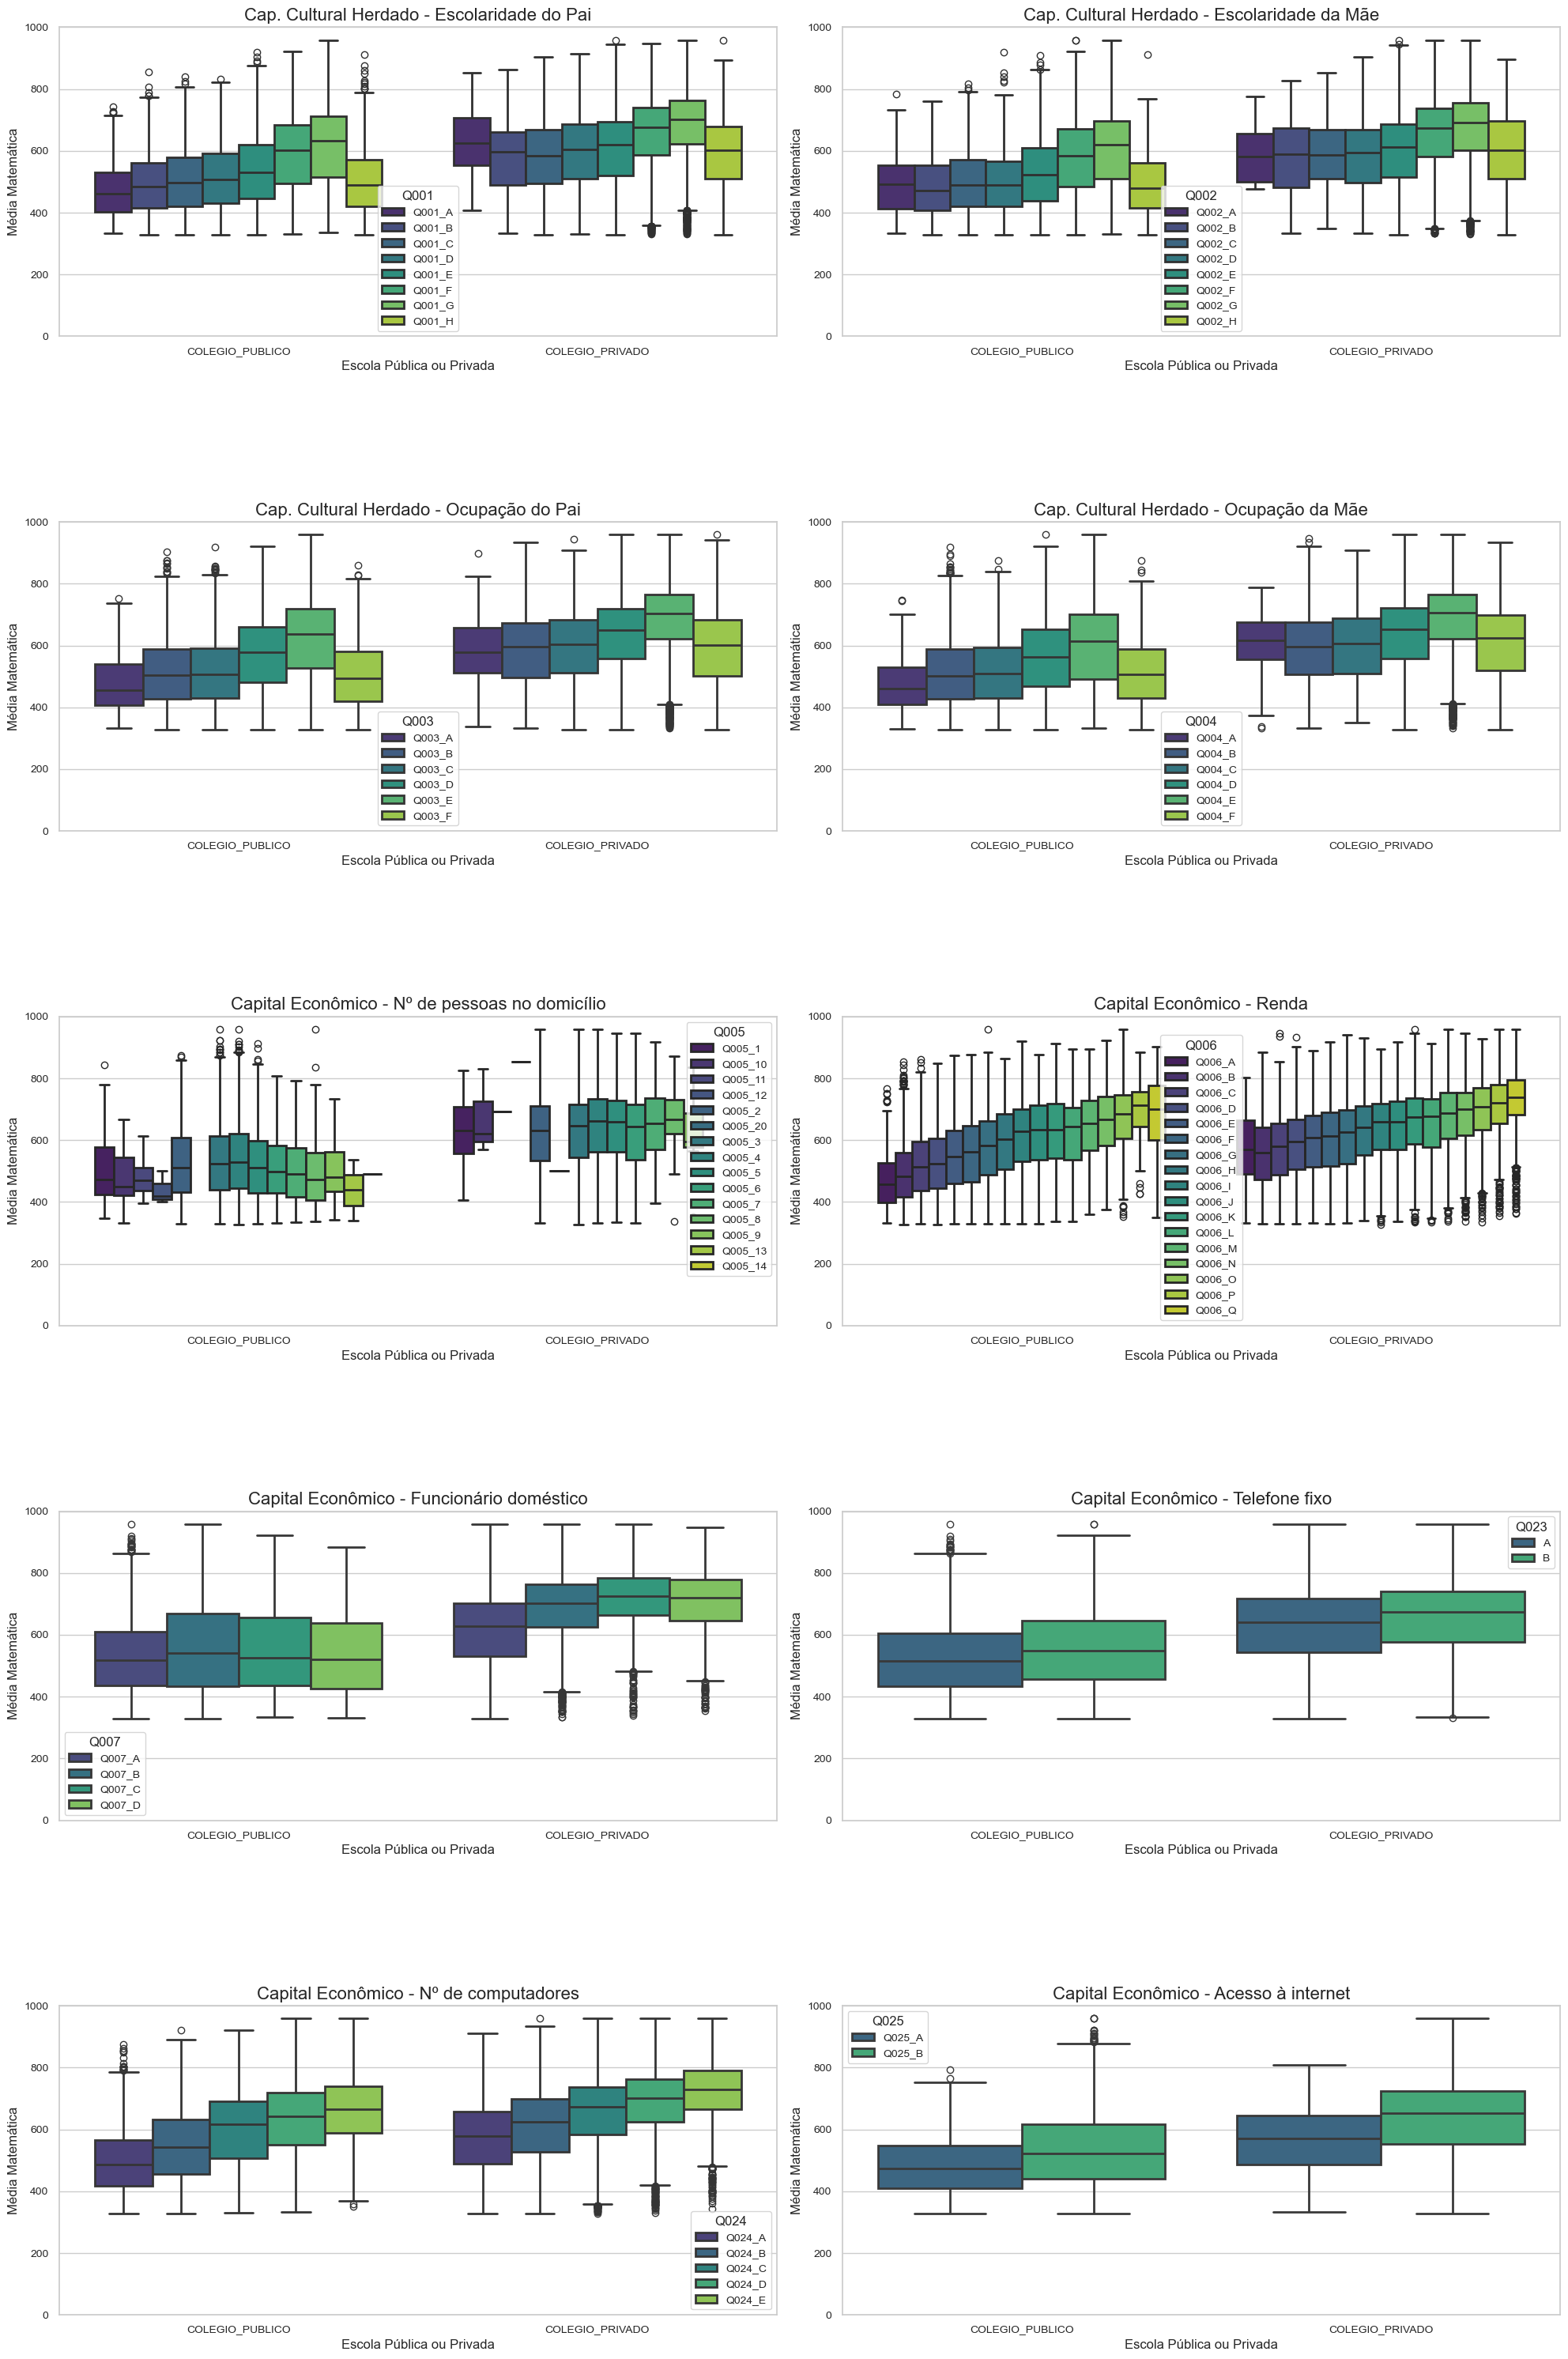

In [257]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# ===== 0) Conversão robusta (1.234,5 | 365,3 | 365.3) =====
def smart_to_float(x):
    s = str(x).strip()
    if s == "" or s.lower() in {"nan", "none"}:
        return np.nan
    if "," in s and "." in s:          # "1.234,56" -> milhar ".", decimal ","
        s = s.replace(".", "").replace(",", ".")
    elif "," in s:                     # "365,3" -> vírgula decimal
        s = s.replace(",", ".")
    try:
        return float(s)
    except:
        return np.nan

df_01 = Educacao_enem_bin_mt_muni_02_RJ.copy()

# Converte NU_NOTA_MT
df_01["NU_NOTA_MT"] = df_01["NU_NOTA_MT"].apply(smart_to_float)

# (Opcional) Mapear TP_ESCOLA se vier codificado
if pd.api.types.is_integer_dtype(df_01["TP_ESCOLA"]) or pd.api.types.is_float_dtype(df_01["TP_ESCOLA"]):
    df["TP_ESCOLA"] = df_01["TP_ESCOLA"].map({1: "Pública", 2: "Privada"}).fillna(df_01["TP_ESCOLA"])

df_01["TP_ESCOLA"] = df_01["TP_ESCOLA"].astype(str)

# ===== 1) Função para boxplot (robusta) =====
def plot_boxplot(ax, sorted_df, ordem_categorias, hue_col, title):
    cols = ["TP_ESCOLA", "NU_NOTA_MT", hue_col]
    falt = [c for c in cols if c not in sorted_df.columns]
    if falt:
        ax.text(0.5, 0.5, f"Coluna(s) ausente(s): {', '.join(falt)}", ha="center", va="center")
        ax.set_axis_off()
        return

    sub = sorted_df.loc[:, cols].dropna(subset=["TP_ESCOLA", "NU_NOTA_MT"]).copy()
    # se quiser exigir hue não nulo, mantenha a linha abaixo; caso contrário, comente:
    sub = sub.dropna(subset=[hue_col])

    if sub.empty:
        ax.text(0.5, 0.5, "Sem dados válidos", ha="center", va="center")
        ax.set_axis_off()
        return

    # Garante TODAS as categorias do eixo X
    sub["TP_ESCOLA"] = pd.Categorical(sub["TP_ESCOLA"],
                                      categories=list(ordem_categorias),
                                      ordered=True)
    sub[hue_col] = sub[hue_col].astype(str)

    sns.boxplot(data=sub, x='TP_ESCOLA', y='NU_NOTA_MT',
                linewidth=2, orient='v', palette='viridis',
                order=list(ordem_categorias), hue=hue_col, ax=ax)

    ax.set_title(title, fontsize=16)
    ax.set_ylabel('Média Matemática', fontsize=12)
    ax.set_xlabel('Escola Pública ou Privada', fontsize=12)
    ax.tick_params(axis='x', rotation=0, labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    ax.set_ylim(0, 1000)
    ax.legend(fontsize=10, title=hue_col, frameon=True, loc="best")

# ===== Subplots (figura mais alta para não achatar) =====
fig, axs = plt.subplots(5, 2, figsize=(20, 30))
fig.tight_layout(pad=5.0)

# ===== Ordem das categorias por mediana (com dados válidos) =====
base_ordem = df.dropna(subset=["TP_ESCOLA", "NU_NOTA_MT"])
medianas = base_ordem.groupby('TP_ESCOLA')["NU_NOTA_MT"].median().sort_values()
ordem_categorias = medianas.index  # ex.: ['Pública','Privada']

# ===== Plots =====
plot_boxplot(axs[0, 0], df_01.sort_values(by=['TP_ESCOLA', 'Q001'], na_position='last'),
             ordem_categorias, 'Q001', 'Cap. Cultural Herdado - Escolaridade do Pai')

plot_boxplot(axs[0, 1], df_01.sort_values(by=['TP_ESCOLA', 'Q002'], na_position='last'),
             ordem_categorias, 'Q002', 'Cap. Cultural Herdado - Escolaridade da Mãe')

plot_boxplot(axs[1, 0], df_01.sort_values(by=['TP_ESCOLA', 'Q003'], na_position='last'),
             ordem_categorias, 'Q003', 'Cap. Cultural Herdado - Ocupação do Pai')

plot_boxplot(axs[1, 1], df_01.sort_values(by=['TP_ESCOLA', 'Q004'], na_position='last'),
             ordem_categorias, 'Q004', 'Cap. Cultural Herdado - Ocupação da Mãe')

plot_boxplot(axs[2, 0], df_01.sort_values(by=['TP_ESCOLA', 'Q005'], na_position='last'),
             ordem_categorias, 'Q005', 'Capital Econômico - Nº de pessoas no domicílio')

plot_boxplot(axs[2, 1], df_01.sort_values(by=['TP_ESCOLA', 'Q006'], na_position='last'),
             ordem_categorias, 'Q006', 'Capital Econômico - Renda')

plot_boxplot(axs[3, 0], df_01.sort_values(by=['TP_ESCOLA', 'Q007'], na_position='last'),
             ordem_categorias, 'Q007', 'Capital Econômico - Funcionário doméstico')

plot_boxplot(axs[3, 1], df_01.sort_values(by=['TP_ESCOLA', 'Q023'], na_position='last'),
             ordem_categorias, 'Q023', 'Capital Econômico - Telefone fixo')

plot_boxplot(axs[4, 0], df_01.sort_values(by=['TP_ESCOLA', 'Q024'], na_position='last'),
             ordem_categorias, 'Q024', 'Capital Econômico - Nº de computadores')

plot_boxplot(axs[4, 1], df_01.sort_values(by=['TP_ESCOLA', 'Q025'], na_position='last'),
             ordem_categorias, 'Q025', 'Capital Econômico - Acesso à internet')

plt.tight_layout()
plt.subplots_adjust(hspace=0.6)
plt.show()

In [258]:
print(df_01["NU_NOTA_MT"].describe())
print(df_01["TP_ESCOLA"].unique())
for q in ["Q001","Q002","Q003","Q004","Q005","Q006","Q007","Q023","Q024","Q025"]:
    print(q, df_01[["TP_ESCOLA","NU_NOTA_MT", q]].dropna().shape[0])

count    33758.000000
mean       580.899502
std        129.361097
min        328.200000
25%        477.325000
50%        582.050000
75%        680.600000
max        958.600000
Name: NU_NOTA_MT, dtype: float64
['COLEGIO_PUBLICO' 'COLEGIO_PRIVADO']
Q001 33758
Q002 33758
Q003 33758
Q004 33758
Q005 33758
Q006 33758
Q007 33758
Q023 33758
Q024 33758
Q025 33758


## REDAÇÃO

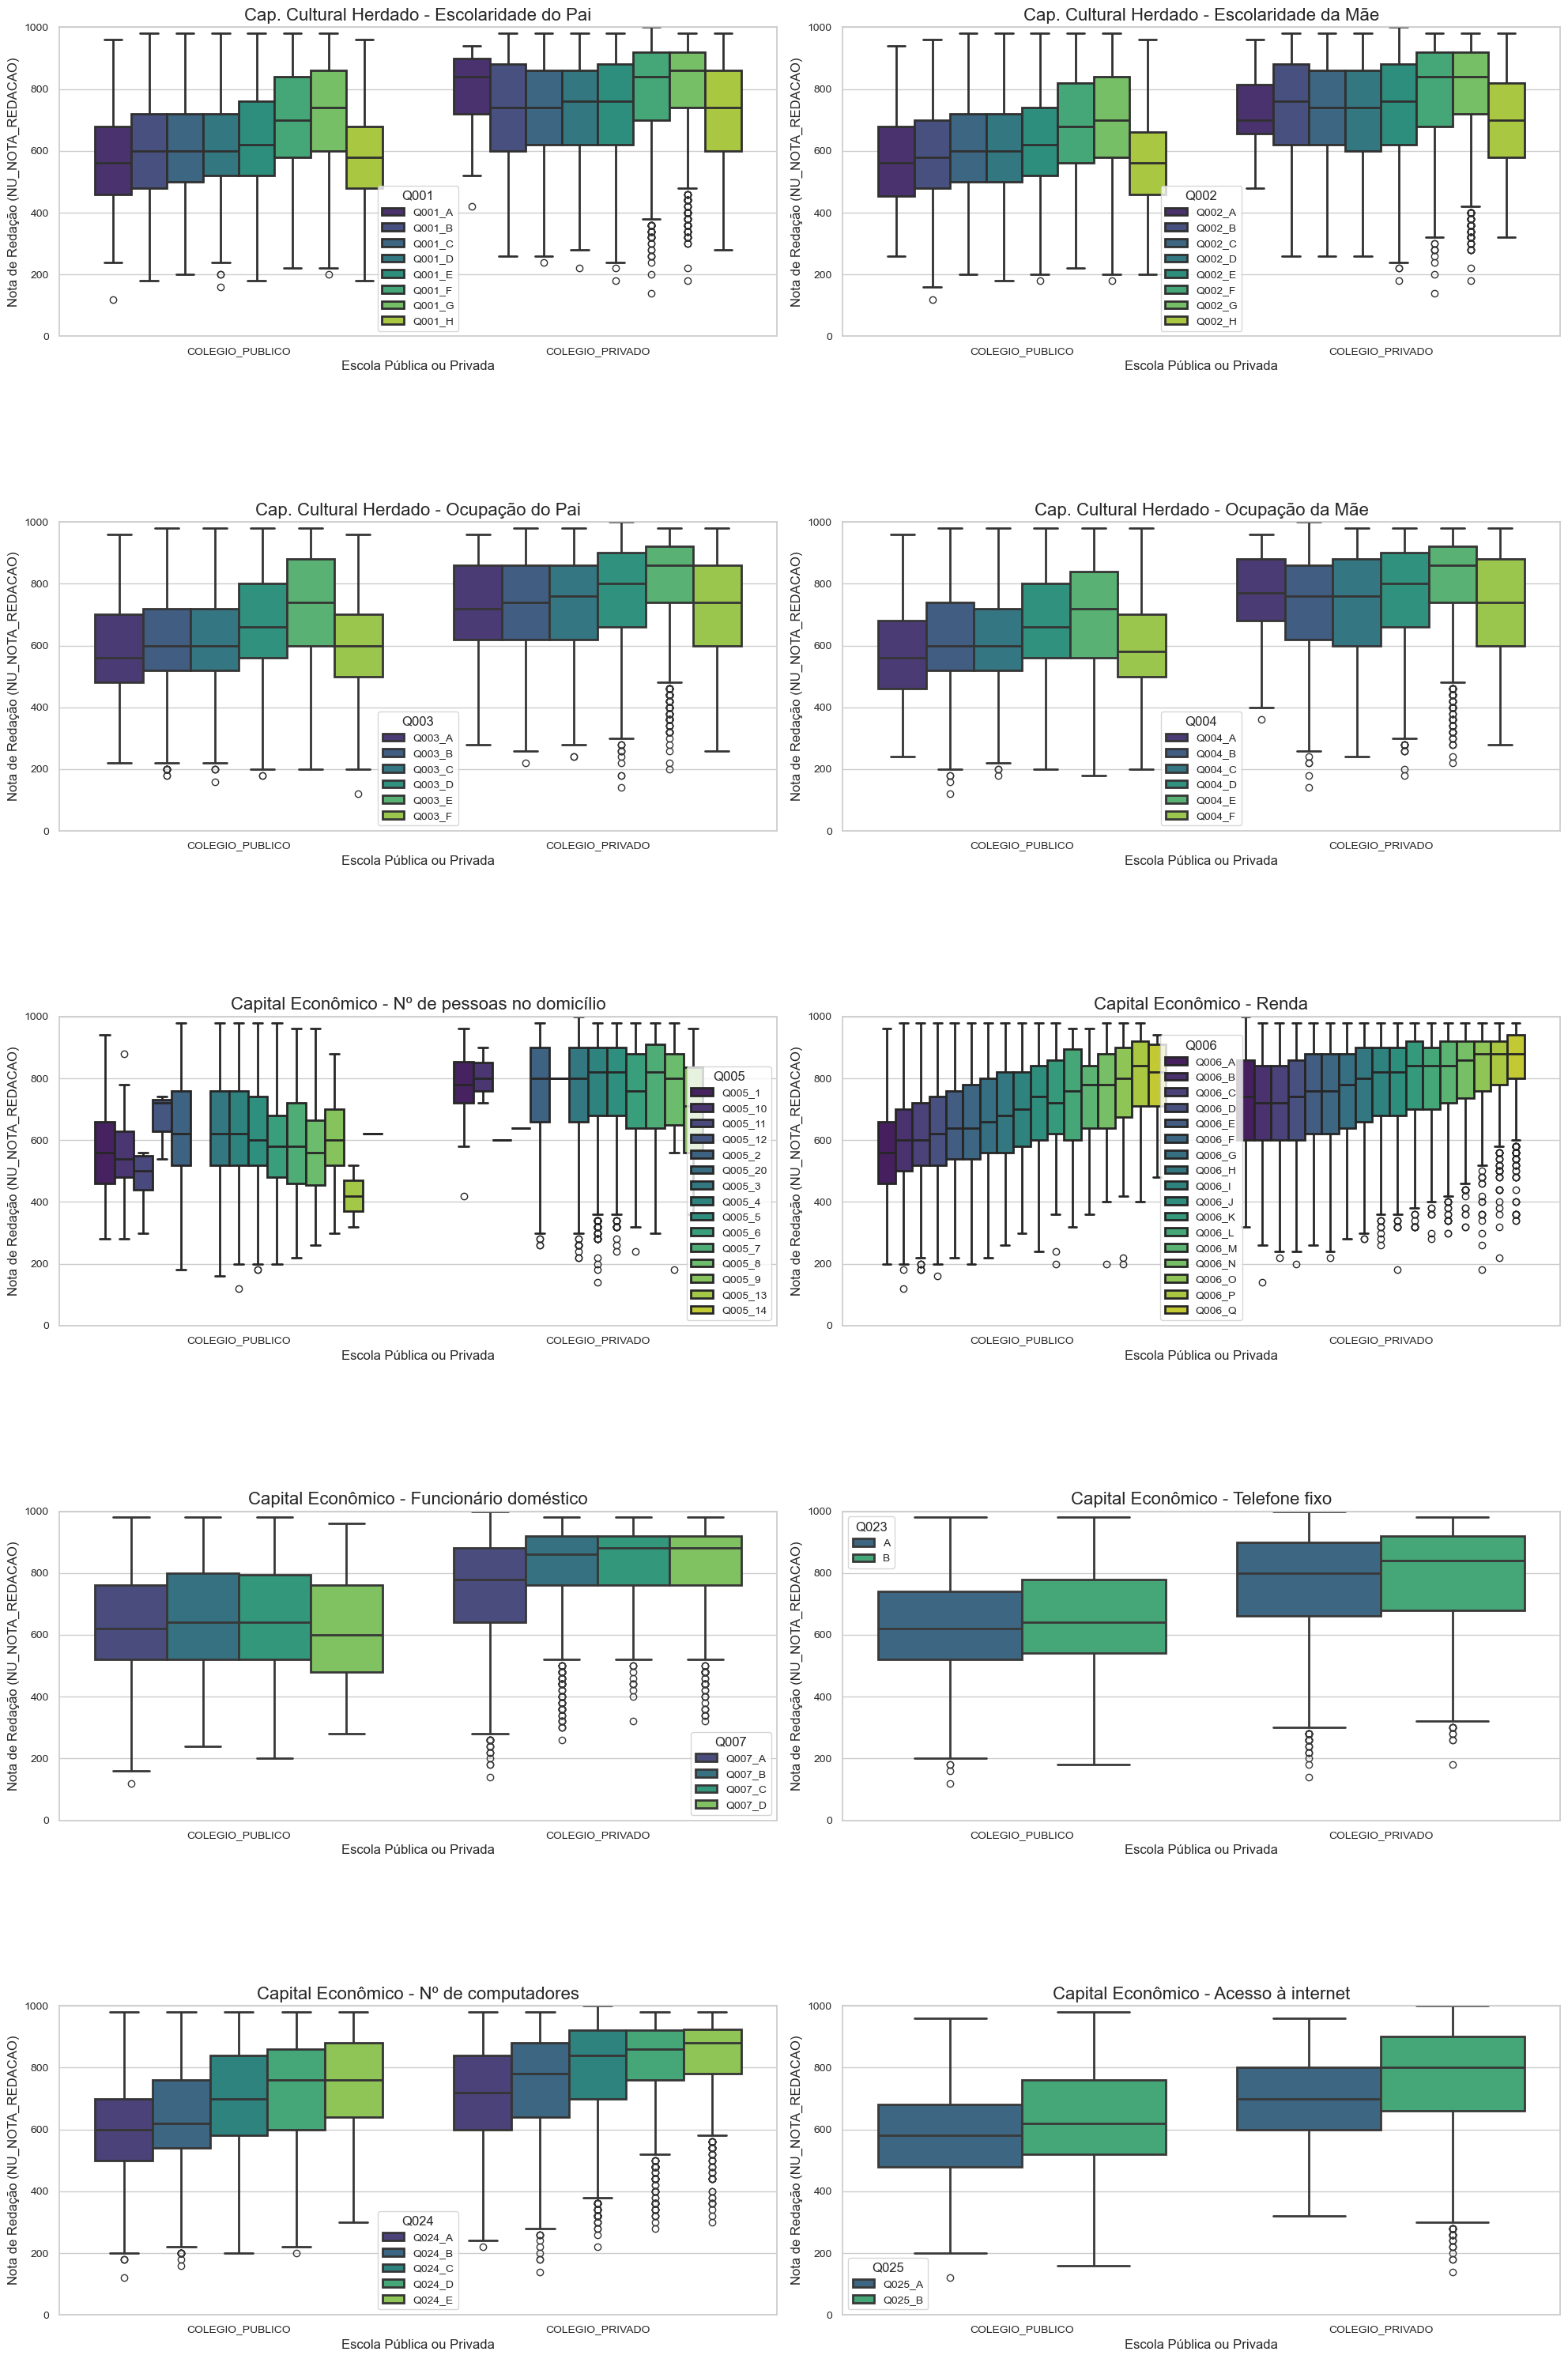

In [259]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# ===== 0) Conversão robusta de NU_NOTA_REDACAO =====
def smart_to_float(x):
    s = str(x).strip()
    if s == "" or s.lower() in {"nan", "none"}:
        return np.nan
    if "," in s and "." in s:          # "1.234,56" -> milhar ".", decimal ","
        s = s.replace(".", "").replace(",", ".")
    elif "," in s:                     # "365,3"
        s = s.replace(",", ".")
    try:
        return float(s)
    except:
        return np.nan

df = Educacao_enem_bin_mt_muni_02_RJ.copy()
df["NU_NOTA_REDACAO"] = df["NU_NOTA_REDACAO"].apply(smart_to_float)

# (Opcional) Mapear TP_ESCOLA (se vier 1/2)
if pd.api.types.is_integer_dtype(df["TP_ESCOLA"]) or pd.api.types.is_float_dtype(df["TP_ESCOLA"]):
    df["TP_ESCOLA"] = df["TP_ESCOLA"].map({1: "Pública", 2: "Privada"}).fillna(df["TP_ESCOLA"])
df["TP_ESCOLA"] = df["TP_ESCOLA"].astype(str)

# ===== 1) Função para criar os gráficos de boxplot (robusta) =====
def plot_boxplot(ax, sorted_df, ordem_categorias, hue_col, title):
    cols = ["TP_ESCOLA", "NU_NOTA_REDACAO", hue_col]
    falt = [c for c in cols if c not in sorted_df.columns]
    if falt:
        ax.text(0.5, 0.5, f"Coluna(s) ausente(s): {', '.join(falt)}",
                ha="center", va="center")
        ax.set_axis_off()
        return

    sub = sorted_df.loc[:, cols].dropna(subset=["TP_ESCOLA", "NU_NOTA_REDACAO"]).copy()
    # se quiser exigir hue não nulo, mantenha a linha abaixo; caso contrário, comente:
    sub = sub.dropna(subset=[hue_col])

    if sub.empty:
        ax.text(0.5, 0.5, "Sem dados válidos", ha="center", va="center")
        ax.set_axis_off()
        return

    # Garante TODAS as categorias do eixo X
    sub["TP_ESCOLA"] = pd.Categorical(sub["TP_ESCOLA"],
                                      categories=list(ordem_categorias),
                                      ordered=True)
    sub[hue_col] = sub[hue_col].astype(str)

    sns.boxplot(data=sub, x='TP_ESCOLA', y='NU_NOTA_REDACAO',
                linewidth=2, orient='v', palette='viridis',
                order=list(ordem_categorias), hue=hue_col, ax=ax)

    ax.set_title(title, fontsize=16)
    ax.set_ylabel('Nota de Redação (NU_NOTA_REDACAO)', fontsize=12)
    ax.set_xlabel('Escola Pública ou Privada', fontsize=12)
    ax.tick_params(axis='x', rotation=0, labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    ax.set_ylim(0, 1000)  # escala típica
    ax.legend(fontsize=10, title=hue_col, frameon=True, loc="best")

# ===== Subplots (alto para não achatar) =====
fig, axs = plt.subplots(5, 2, figsize=(20, 30))
fig.tight_layout(pad=5.0)

# ===== Ordem das categorias por mediana (com dados válidos) =====
base_ordem = df.dropna(subset=["TP_ESCOLA", "NU_NOTA_REDACAO"])
medianas = base_ordem.groupby('TP_ESCOLA')["NU_NOTA_REDACAO"].median().sort_values()
ordem_categorias = medianas.index  # ex.: ['Pública','Privada']

# ===== Gráficos =====
plot_boxplot(axs[0, 0], df.sort_values(by=['TP_ESCOLA', 'Q001'], na_position='last'),
             ordem_categorias, 'Q001', 'Cap. Cultural Herdado - Escolaridade do Pai')

plot_boxplot(axs[0, 1], df.sort_values(by=['TP_ESCOLA', 'Q002'], na_position='last'),
             ordem_categorias, 'Q002', 'Cap. Cultural Herdado - Escolaridade da Mãe')

plot_boxplot(axs[1, 0], df.sort_values(by=['TP_ESCOLA', 'Q003'], na_position='last'),
             ordem_categorias, 'Q003', 'Cap. Cultural Herdado - Ocupação do Pai')

plot_boxplot(axs[1, 1], df.sort_values(by=['TP_ESCOLA', 'Q004'], na_position='last'),
             ordem_categorias, 'Q004', 'Cap. Cultural Herdado - Ocupação da Mãe')

plot_boxplot(axs[2, 0], df.sort_values(by=['TP_ESCOLA', 'Q005'], na_position='last'),
             ordem_categorias, 'Q005', 'Capital Econômico - Nº de pessoas no domicílio')

plot_boxplot(axs[2, 1], df.sort_values(by=['TP_ESCOLA', 'Q006'], na_position='last'),
             ordem_categorias, 'Q006', 'Capital Econômico - Renda')

plot_boxplot(axs[3, 0], df.sort_values(by=['TP_ESCOLA', 'Q007'], na_position='last'),
             ordem_categorias, 'Q007', 'Capital Econômico - Funcionário doméstico')

# Corrigido: usar os dataframes certos nos últimos 3
plot_boxplot(axs[3, 1], df.sort_values(by=['TP_ESCOLA', 'Q023'], na_position='last'),
             ordem_categorias, 'Q023', 'Capital Econômico - Telefone fixo')

plot_boxplot(axs[4, 0], df.sort_values(by=['TP_ESCOLA', 'Q024'], na_position='last'),
             ordem_categorias, 'Q024', 'Capital Econômico - Nº de computadores')

plot_boxplot(axs[4, 1], df.sort_values(by=['TP_ESCOLA', 'Q025'], na_position='last'),
             ordem_categorias, 'Q025', 'Capital Econômico - Acesso à internet')

plt.tight_layout()
plt.subplots_adjust(hspace=0.6)
plt.show()

In [262]:
## Importação dos datasets: Lista das regiões que foram integradas ao banco para discussão de diferenças de desempenho 
## entre os alunos da capital metropolitana e das mesorregiões 

import pandas as pd
import os

def load_dados_enem_micro(dados_path, file_name):
    """
    Função para carregar um arquivo CSV a partir de um diretório específico.
    
    Parameters:
    dados_path (str): O caminho para o diretório onde os arquivos CSV estão localizados.
    file_name (str): O nome do arquivo CSV a ser carregado.
    
    Returns:
    pd.DataFrame: DataFrame contendo os dados do arquivo CSV.
    """
    # Constrói o caminho completo para o arquivo CSV
    csv_path = os.path.join(dados_path, file_name)
    
    # C
    #Carrega o arquivo CSV em um DataFrame
    return pd.read_csv(csv_path, sep=";", encoding="utf-8", decimal=",", thousands=".")

# Exemplo de uso:
dados_path = "C:/Users/DELL/OneDrive/Documentos/Projeto_revisão_TCC"  # Substitua pelo caminho real
file_name = "Banco_dados_RJ_Mesoregioes_capital_DEP_ADM.csv"

# Detalhes da Amostra

## Regiões  
'''
## Categorias das Mesoregiões 
mesoregioes = {
    'Norte_Fluminense': ['Campos_dos_Goytacazes', 'Sao_Fidelis', 'Sao_Francisco_de_Itabapoana', 'Macae', 'Quissama'],
    'Noroeste_Fluminense': ['Bom_Jesus_do_Itabopoana', 'Itaperuna', 'Itaocara', 'Miracema', 'Santo_Antonio_de_Padua'],
    'Centro_Fluminense': ['Nova_Friburgo', 'Casimiro_de_Abreu', 'Rio_das_Ostras', 'Araruama', 'Cabo_Frio', 'Iguaba_Grande', 'Sao_Pedro_da_Aldeia', 'Saquarema'],
    'Sul_Fluminense': ['Barra_Mansa', 'Itatiaia', 'Resende', 'Rio_claro', 'Volta_Redonda', 'Barra_do_Pirai', 'Valenca', 'Paraty']    
}
'''

## Capital Metropolitana: Rio de Janeiro


# Carrega os dados do arquivo CSV
dfm = load_dados_enem_micro(dados_path, file_name)

# Exibindo as primeiras linhas do DataFrame para verificar o conteúdo
print(dfm.head())


   NU_INSCRICAO    Q001    Q002    Q003    Q004    Q005    Q006    Q007  \
0  210061234984  Q001_D  Q002_E  Q003_D  Q004_B  Q005_2  Q006_D  Q007_A   
1  210059974463  Q001_B  Q002_D  Q003_C  Q004_B  Q005_4  Q006_B  Q007_A   
2  210058387339  Q001_B  Q002_D  Q003_B  Q004_D  Q005_1  Q006_B  Q007_A   
3  210058073304  Q001_D  Q002_G  Q003_C  Q004_D  Q005_2  Q006_B  Q007_A   
4  210059855138  Q001_B  Q002_D  Q003_C  Q004_B  Q005_4  Q006_A  Q007_B   

     Q008    Q009  ... TP_SEXO TP_DEPENDENCIA_ADM_ESC NO_MUNICIPIO_PROVA  \
0  Q008_C  Q009_C  ...       M                FEDERAL            Valença   
1  Q008_B  Q009_C  ...       F               ESTADUAL     Rio de Janeiro   
2  Q008_B  Q009_B  ...       M                FEDERAL     Rio de Janeiro   
3  Q008_B  Q009_D  ...       F                FEDERAL            Valença   
4  Q008_B  Q009_B  ...       F               ESTADUAL     Rio de Janeiro   

  NU_NOTA_MT NU_NOTA_REDACAO    Q005_z TP_FAIXA_ETARIA_z  \
0      645.6             680 -1.

In [263]:
## Retirando opção não respondeu: Mesorregiões
Educacao_enem_bin_mt_muni_02_mesorregiao = dfm[dfm['TP_ESCOLA'] != 'Naorespondeu']
Educacao_enem_bin_mt_muni_02_mesorregiao = dfm[dfm['Mesorregiao'] != 'Capital Metropolitana']
Educacao_enem_bin_mt_muni_02_mesorregiao

,NU_INSCRICAO,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,...,TP_SEXO,TP_DEPENDENCIA_ADM_ESC,NO_MUNICIPIO_PROVA,NU_NOTA_MT,NU_NOTA_REDACAO,Q005_z,TP_FAIXA_ETARIA_z,Mesorregiao,NO_MUNICIPIO_PROVA_N,NO_MUNICIPIO_PROVA_PAD
0,210061234984,Q001_D,Q002_E,Q003_D,Q004_B,Q005_2,Q006_D,Q007_A,Q008_C,Q009_C,...,M,FEDERAL,Valença,645.6,680,-1.315109,-0.311344,Sul Fluminense,,VALENCA
3,210058073304,Q001_D,Q002_G,Q003_C,Q004_D,Q005_2,Q006_B,Q007_A,Q008_B,Q009_D,...,F,FEDERAL,Valença,648.8,880,-1.315109,0.148027,Sul Fluminense,,VALENCA
8,210059993982,Q001_B,Q002_C,Q003_A,Q004_B,Q005_4,Q006_E,Q007_A,Q008_B,Q009_D,...,F,ESTADUAL,Paraty,384.1,320,0.151517,-0.311344,Sul Fluminense,,PARATY
9,210058573855,Q001_G,Q002_F,Q003_D,Q004_D,Q005_5,Q006_J,Q007_A,Q008_C,Q009_D,...,F,ESTADUAL,São Fidélis,701.3,860,0.884830,-0.311344,Norte Fluminense,,SAO FIDELIS
15,210059401180,Q001_E,Q002_E,Q003_C,Q004_F,Q005_8,Q006_E,Q007_A,Q008_B,Q009_D,...,F,ESTADUAL,Nova Friburgo,384.5,600,3.084769,-0.311344,Centro Fluminense,,NOVA FRIBURGO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45074,210059112393,Q001_E,Q002_F,Q003_C,Q004_D,Q005_3,Q006_G,Q007_A,Q008_C,Q009_C,...,M,FEDERAL,Rio das Ostras,677.5,620,-0.581796,-0.311344,Centro Fluminense,,RIO DAS OSTRAS
45077,210060069349,Q001_H,Q002_E,Q003_F,Q004_B,Q005_3,Q006_C,Q007_A,Q008_C,Q009_C,...,M,ESTADUAL,São Pedro da Aldeia,416.6,660,-0.581796,-0.311344,Centro Fluminense,,SAO PEDRO DA ALDEIA
45079,210061345757,Q001_D,Q002_E,Q003_B,Q004_B,Q005_4,Q006_B,Q007_A,Q008_B,Q009_C,...,F,ESTADUAL,Itaperuna,441.4,500,0.151517,-0.770714,Noroeste Fluminense,,ITAPERUNA
45084,210059003779,Q001_E,Q002_E,Q003_B,Q004_B,Q005_3,Q006_C,Q007_A,Q008_B,Q009_D,...,F,ESTADUAL,Resende,633.4,620,-0.581796,-0.311344,Sul Fluminense,,RESENDE


## MATEMÁTICA

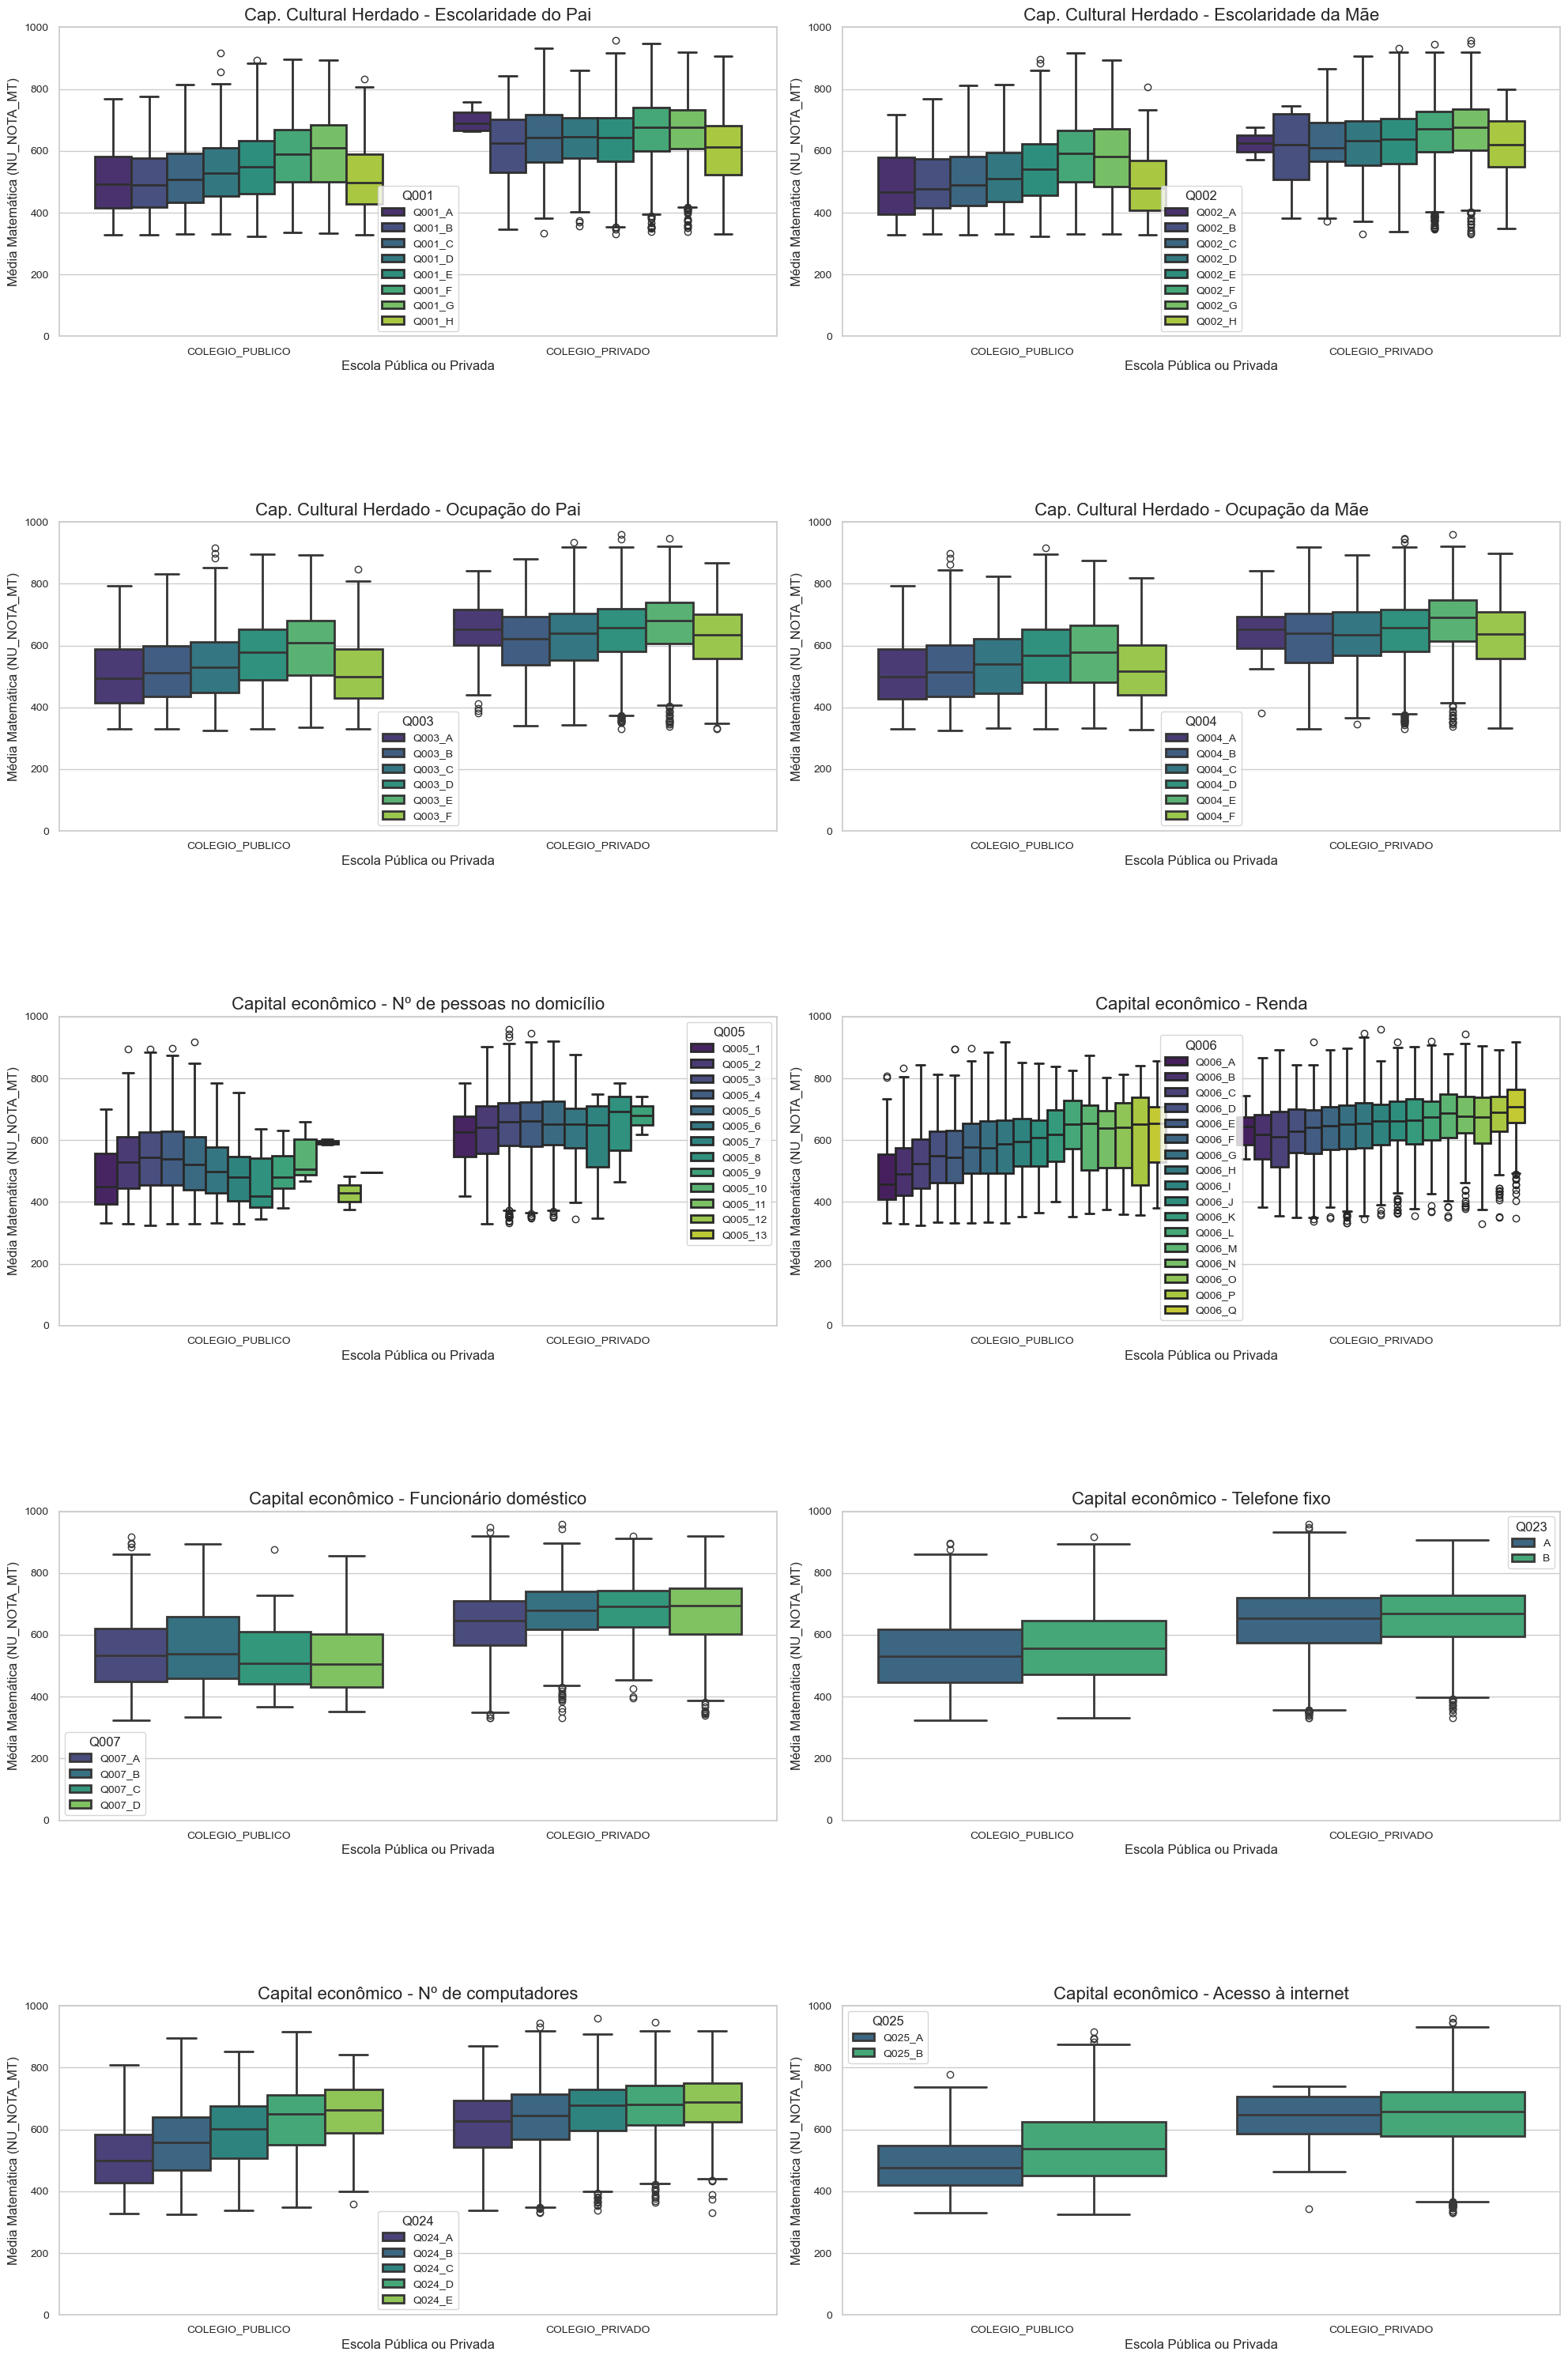

In [264]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# ===== 0) Conversão robusta para NU_NOTA_MT =====
def smart_to_float(x):
    s = str(x).strip()
    if s == "" or s.lower() in {"nan", "none"}:
        return np.nan
    if "," in s and "." in s:          # "1.234,56" -> milhar ".", decimal ","
        s = s.replace(".", "").replace(",", ".")
    elif "," in s:                     # "365,3"
        s = s.replace(",", ".")
    try:
        return float(s)
    except:
        return np.nan

dfm = Educacao_enem_bin_mt_muni_02_Meso.copy()
dfm["NU_NOTA_MT"] = dfm["NU_NOTA_MT"].apply(smart_to_float)

# (Opcional) mapear TP_ESCOLA se vier 1/2
if pd.api.types.is_integer_dtype(dfm["TP_ESCOLA"]) or pd.api.types.is_float_dtype(dfm["TP_ESCOLA"]):
    dfm["TP_ESCOLA"] = dfm["TP_ESCOLA"].map({1: "Pública", 2: "Privada"}).fillna(dfm["TP_ESCOLA"])
dfm["TP_ESCOLA"] = dfm["TP_ESCOLA"].astype(str)

# ===== 1) Função de boxplot (robusta) =====
def plot_boxplot(ax, sorted_df, ordem_categorias, hue_col, title):
    cols = ["TP_ESCOLA", "NU_NOTA_MT", hue_col]
    falt = [c for c in cols if c not in sorted_df.columns]
    if falt:
        ax.text(0.5, 0.5, f"Coluna(s) ausente(s): {', '.join(falt)}", ha="center", va="center")
        ax.set_axis_off()
        return

    sub = sorted_df.loc[:, cols].dropna(subset=["TP_ESCOLA", "NU_NOTA_MT"]).copy()
    # se quiser exigir hue não nulo, mantenha a linha abaixo; caso contrário, comente:
    sub = sub.dropna(subset=[hue_col])

    if sub.empty:
        ax.text(0.5, 0.5, "Sem dados válidos", ha="center", va="center")
        ax.set_axis_off()
        return

    # garantir TODAS as categorias do eixo X
    sub["TP_ESCOLA"] = pd.Categorical(sub["TP_ESCOLA"],
                                      categories=list(ordem_categorias),
                                      ordered=True)
    sub[hue_col] = sub[hue_col].astype(str)

    sns.boxplot(
        data=sub, x='TP_ESCOLA', y='NU_NOTA_MT',
        order=list(ordem_categorias), hue=hue_col,
        linewidth=2, orient='v', palette='viridis', ax=ax
    )

    ax.set_title(title, fontsize=16)
    ax.set_ylabel('Média Matemática (NU_NOTA_MT)', fontsize=12)
    ax.set_xlabel('Escola Pública ou Privada', fontsize=12)
    ax.tick_params(axis='x', rotation=0, labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    ax.set_ylim(0, 1000)
    ax.legend(fontsize=10, title=hue_col, frameon=True, loc="best")

# ===== Subplots (alto para não achatar) =====
fig, axs = plt.subplots(5, 2, figsize=(20, 30))
fig.tight_layout(pad=5.0)

# ===== Ordem das categorias por mediana (com dados válidos) =====
base_ordem = dfm.dropna(subset=["TP_ESCOLA", "NU_NOTA_MT"])
medianas = base_ordem.groupby('TP_ESCOLA')["NU_NOTA_MT"].median().sort_values()
ordem_categorias = medianas.index  # e.g., ['Pública','Privada']

# ===== Gráficos =====
plot_boxplot(axs[0, 0], dfm.sort_values(by=['TP_ESCOLA', 'Q001'], na_position='last'),
             ordem_categorias, 'Q001', 'Cap. Cultural Herdado - Escolaridade do Pai')

plot_boxplot(axs[0, 1], dfm.sort_values(by=['TP_ESCOLA', 'Q002'], na_position='last'),
             ordem_categorias, 'Q002', 'Cap. Cultural Herdado - Escolaridade da Mãe')

plot_boxplot(axs[1, 0], dfm.sort_values(by=['TP_ESCOLA', 'Q003'], na_position='last'),
             ordem_categorias, 'Q003', 'Cap. Cultural Herdado - Ocupação do Pai')

plot_boxplot(axs[1, 1], dfm.sort_values(by=['TP_ESCOLA', 'Q004'], na_position='last'),
             ordem_categorias, 'Q004', 'Cap. Cultural Herdado - Ocupação da Mãe')

plot_boxplot(axs[2, 0], dfm.sort_values(by=['TP_ESCOLA', 'Q005'], na_position='last'),
             ordem_categorias, 'Q005', 'Capital econômico - Nº de pessoas no domicílio')

plot_boxplot(axs[2, 1], dfm.sort_values(by=['TP_ESCOLA', 'Q006'], na_position='last'),
             ordem_categorias, 'Q006', 'Capital econômico - Renda')

plot_boxplot(axs[3, 0], dfm.sort_values(by=['TP_ESCOLA', 'Q007'], na_position='last'),
             ordem_categorias, 'Q007', 'Capital econômico - Funcionário doméstico')

# corrigidos: usar os dataframes certos nos últimos 3
plot_boxplot(axs[3, 1], dfm.sort_values(by=['TP_ESCOLA', 'Q023'], na_position='last'),
             ordem_categorias, 'Q023', 'Capital econômico - Telefone fixo')

plot_boxplot(axs[4, 0], dfm.sort_values(by=['TP_ESCOLA', 'Q024'], na_position='last'),
             ordem_categorias, 'Q024', 'Capital econômico - Nº de computadores')

plot_boxplot(axs[4, 1], dfm.sort_values(by=['TP_ESCOLA', 'Q025'], na_position='last'),
             ordem_categorias, 'Q025', 'Capital econômico - Acesso à internet')

plt.tight_layout()
plt.subplots_adjust(hspace=0.6)
plt.show()


## REDAÇÃO

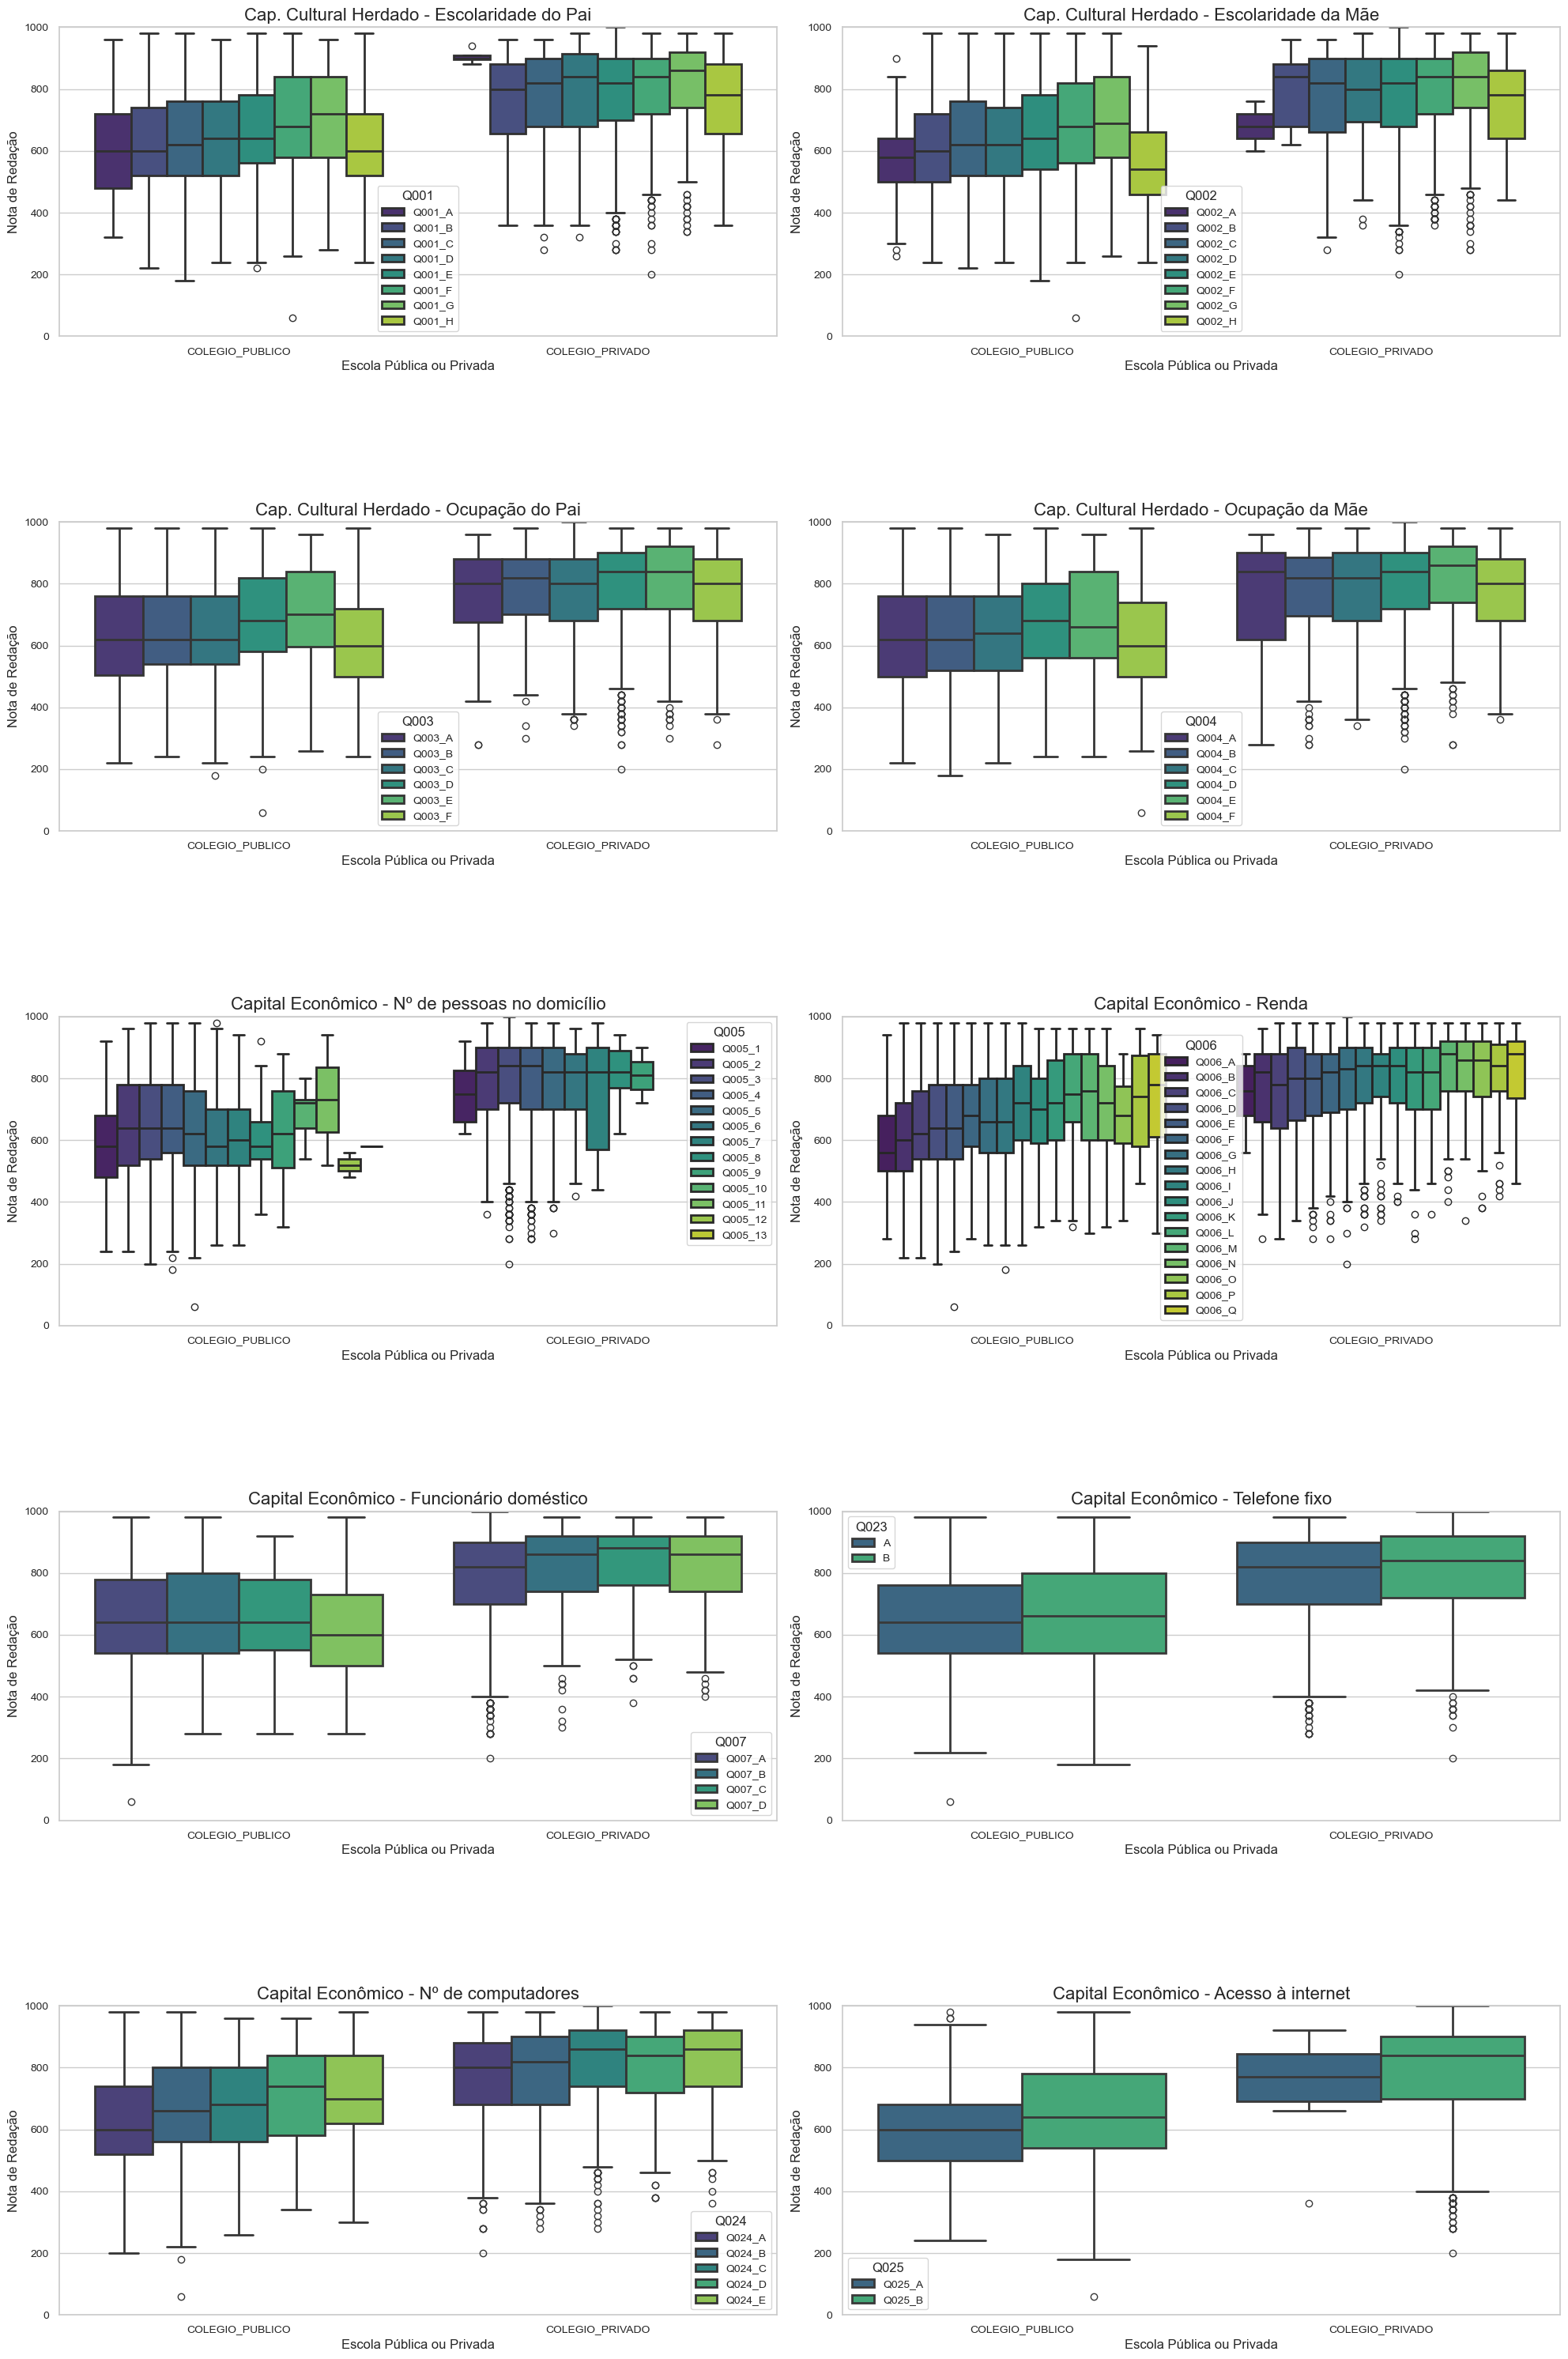

In [266]:
## Box plots para tipo escolar: Redação - Mesorreriões

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# ===== 0) Conversão robusta de NU_NOTA_REDACAO (1.234,5 | 365,3 | 365.3) =====
def smart_to_float(x):
    s = str(x).strip()
    if s == "" or s.lower() in {"nan", "none"}:
        return np.nan
    if "," in s and "." in s:          # "1.234,56" -> milhar ".", decimal ","
        s = s.replace(".", "").replace(",", ".")
    elif "," in s:                     # "365,3"
        s = s.replace(",", ".")
    try:
        return float(s)
    except:
        return np.nan

dfm = Educacao_enem_bin_mt_muni_02_Meso.copy()
dfm["NU_NOTA_REDACAO"] = dfm["NU_NOTA_REDACAO"].apply(smart_to_float)

# (Opcional) Mapear TP_ESCOLA se vier codificado (1/2)
if pd.api.types.is_integer_dtype(dfm["TP_ESCOLA"]) or pd.api.types.is_float_dtype(dfm["TP_ESCOLA"]):
    dfm["TP_ESCOLA"] = dfm["TP_ESCOLA"].map({1: "Pública", 2: "Privada"}).fillna(dfm["TP_ESCOLA"])
dfm["TP_ESCOLA"] = dfm["TP_ESCOLA"].astype(str)

# ===== 1) Função para criar os gráficos de boxplot (robusta) =====
def plot_boxplot(ax, sorted_df, ordem_categorias, hue_col, title):
    cols = ["TP_ESCOLA", "NU_NOTA_REDACAO", hue_col]
    falt = [c for c in cols if c not in sorted_df.columns]
    if falt:
        ax.text(0.5, 0.5, f"Coluna(s) ausente(s): {', '.join(falt)}",
                ha="center", va="center")
        ax.set_axis_off()
        return

    sub = sorted_df.loc[:, cols].dropna(subset=["TP_ESCOLA", "NU_NOTA_REDACAO"]).copy()
    # se quiser exigir hue não nulo, mantenha a linha abaixo; caso contrário, comente:
    sub = sub.dropna(subset=[hue_col])

    if sub.empty:
        ax.text(0.5, 0.5, "Sem dados válidos", ha="center", va="center")
        ax.set_axis_off()
        return

    # Garante TODAS as categorias do eixo X
    sub["TP_ESCOLA"] = pd.Categorical(sub["TP_ESCOLA"],
                                      categories=list(ordem_categorias),
                                      ordered=True)
    sub[hue_col] = sub[hue_col].astype(str)

    sns.boxplot(data=sub, x='TP_ESCOLA', y='NU_NOTA_REDACAO',
                linewidth=2, orient='v', palette='viridis',
                order=list(ordem_categorias), hue=hue_col, ax=ax)

    ax.set_title(title, fontsize=16)
    ax.set_ylabel('Nota de Redação', fontsize=12)
    ax.set_xlabel('Escola Pública ou Privada', fontsize=12)
    ax.tick_params(axis='x', rotation=0, labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    ax.set_ylim(0, 1000)  # escala típica
    ax.legend(fontsize=10, title=hue_col, frameon=True, loc="best")

# ===== Subplots layout (mais alto para não achatar) =====
fig, axs = plt.subplots(5, 2, figsize=(20, 30))
fig.tight_layout(pad=5.0)

# ===== Obtendo medianas e ordem das categorias =====
base_ordem = dfm.dropna(subset=["TP_ESCOLA", "NU_NOTA_REDACAO"])
medianas = base_ordem.groupby('TP_ESCOLA')["NU_NOTA_REDACAO"].median().sort_values()
ordem_categorias = medianas.index  # ex.: ['Pública','Privada']

# ===== Gráficos =====
plot_boxplot(axs[0, 0], dfm.sort_values(by=['TP_ESCOLA', 'Q001'], na_position='last'),
             ordem_categorias, 'Q001', 'Cap. Cultural Herdado - Escolaridade do Pai')

plot_boxplot(axs[0, 1], dfm.sort_values(by=['TP_ESCOLA', 'Q002'], na_position='last'),
             ordem_categorias, 'Q002', 'Cap. Cultural Herdado - Escolaridade da Mãe')

plot_boxplot(axs[1, 0], dfm.sort_values(by=['TP_ESCOLA', 'Q003'], na_position='last'),
             ordem_categorias, 'Q003', 'Cap. Cultural Herdado - Ocupação do Pai')

plot_boxplot(axs[1, 1], dfm.sort_values(by=['TP_ESCOLA', 'Q004'], na_position='last'),
             ordem_categorias, 'Q004', 'Cap. Cultural Herdado - Ocupação da Mãe')

plot_boxplot(axs[2, 0], dfm.sort_values(by=['TP_ESCOLA', 'Q005'], na_position='last'),
             ordem_categorias, 'Q005', 'Capital Econômico - Nº de pessoas no domicílio')

plot_boxplot(axs[2, 1], dfm.sort_values(by=['TP_ESCOLA', 'Q006'], na_position='last'),
             ordem_categorias, 'Q006', 'Capital Econômico - Renda')

plot_boxplot(axs[3, 0], dfm.sort_values(by=['TP_ESCOLA', 'Q007'], na_position='last'),
             ordem_categorias, 'Q007', 'Capital Econômico - Funcionário doméstico')

# corrigidos: usar os dataframes certos nos últimos 3
plot_boxplot(axs[3, 1], dfm.sort_values(by=['TP_ESCOLA', 'Q023'], na_position='last'),
             ordem_categorias, 'Q023', 'Capital Econômico - Telefone fixo')

plot_boxplot(axs[4, 0], dfm.sort_values(by=['TP_ESCOLA', 'Q024'], na_position='last'),
             ordem_categorias, 'Q024', 'Capital Econômico - Nº de computadores')

plot_boxplot(axs[4, 1], dfm.sort_values(by=['TP_ESCOLA', 'Q025'], na_position='last'),
             ordem_categorias, 'Q025', 'Capital Econômico - Acesso à internet')

plt.tight_layout()
plt.subplots_adjust(hspace=0.6)
plt.show()

## Caracteristicas Individuais candidatos: panorama geral

## MATEMÁTICA

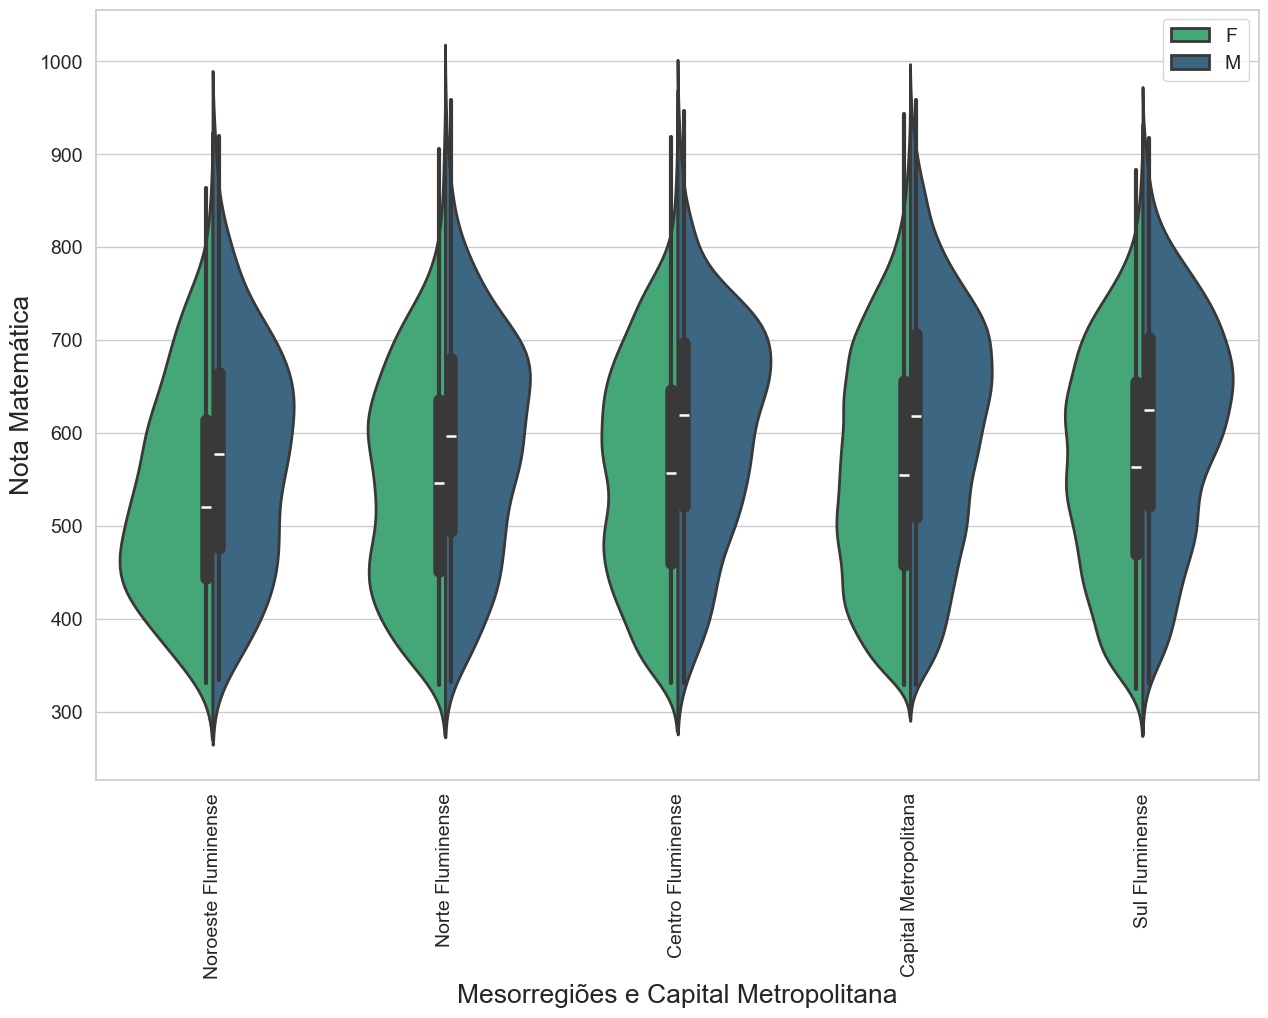

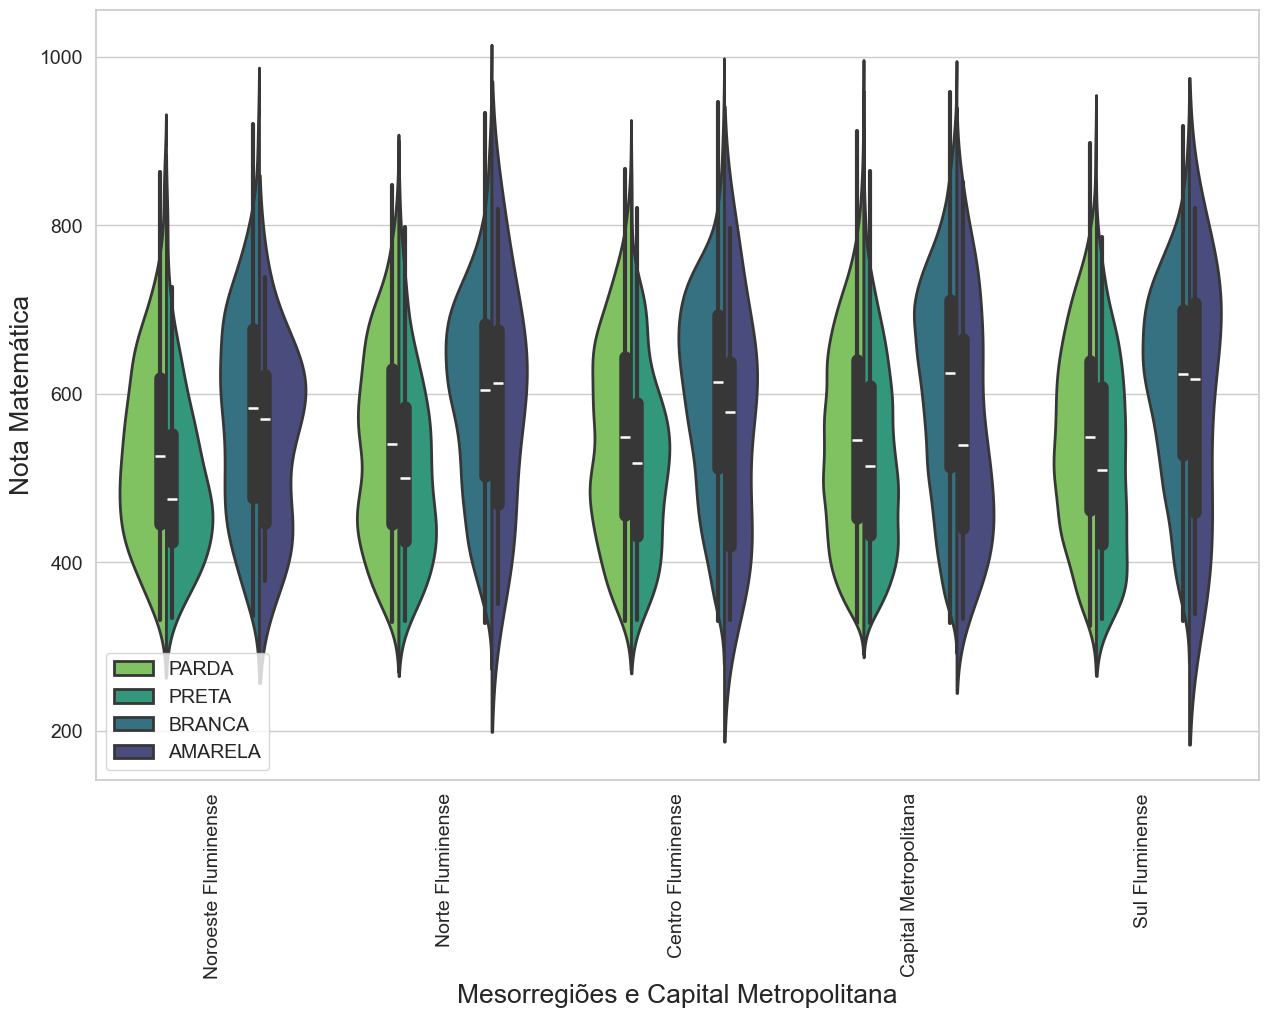

In [271]:
# Ordenando a DataFrame com base na mediana da nota de matemática por mesorregião
medianas = Educacao_enem_bin_mt_muni_02.groupby('Mesorregiao')['NU_NOTA_MT'].median().sort_values()
ordem_categorias = medianas.index

# Ordena o DataFrame baseado em 'Meso_Regiao' e 'Genero'
sorted_df = Educacao_enem_bin_mt_muni_02.sort_values(by=['Mesorregiao', 'TP_SEXO'])

# Criar o gráfico de violino
plt.figure(figsize=(15, 10))
sns.violinplot(data=sorted_df, x='Mesorregiao', y='NU_NOTA_MT', 
               linewidth=2, palette='viridis_r', order=ordem_categorias, hue='TP_SEXO', split=True)
#YlOrBr
# Adicionar uma linha horizontal
#plt.axhline(y=0.00, color='r', linestyle='--', linewidth=2, label='Linha de Referência')

# Customizar o gráfico
plt.ylabel('Nota Matemática', fontsize=19)
plt.xlabel('Mesorregiões e Capital Metropolitana', fontsize=19)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14, rotation=90)

# Opcionalmente adicionar uma legenda
plt.legend(fontsize=14)

medianas = Educacao_enem_bin_mt_muni_02.groupby('Mesorregiao')['NU_NOTA_MT'].median().sort_values()
ordem_categorias = medianas.index

# Ordena o DataFrame baseado em 'Meso_Regiao' e 'Genero'
sorted_df = Educacao_enem_bin_mt_muni_02.sort_values(by=['Mesorregiao', 'TP_SEXO'])

# Criar o gráfico de violino
plt.figure(figsize=(15, 10))
sns.violinplot(data=sorted_df, x='Mesorregiao', y='NU_NOTA_MT', 
               linewidth=2, palette='viridis_r', order=ordem_categorias, hue='TP_COR_RACA', split=True)
#YlOrBr
# Adicionar uma linha horizontal
#plt.axhline(y=0.00, color='r', linestyle='--', linewidth=2, label='Linha de Referência')

# Customizar o gráfico
plt.ylabel('Nota Matemática', fontsize=19)
plt.xlabel('Mesorregiões e Capital Metropolitana', fontsize=19)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14, rotation=90)

# Opcionalmente adicionar uma legenda
plt.legend(fontsize=14)




## REDAÇÃO

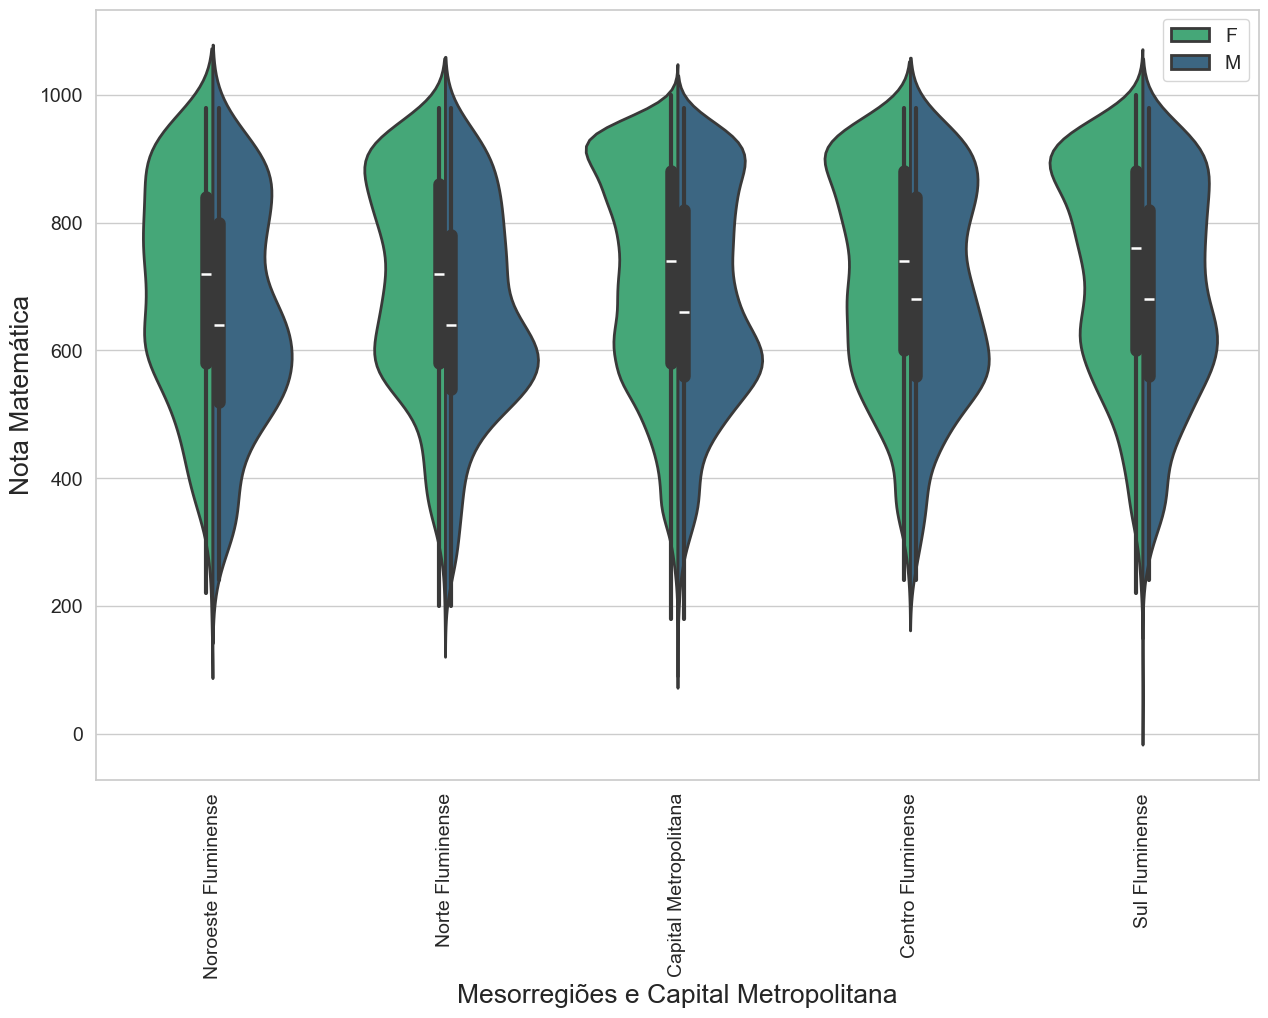

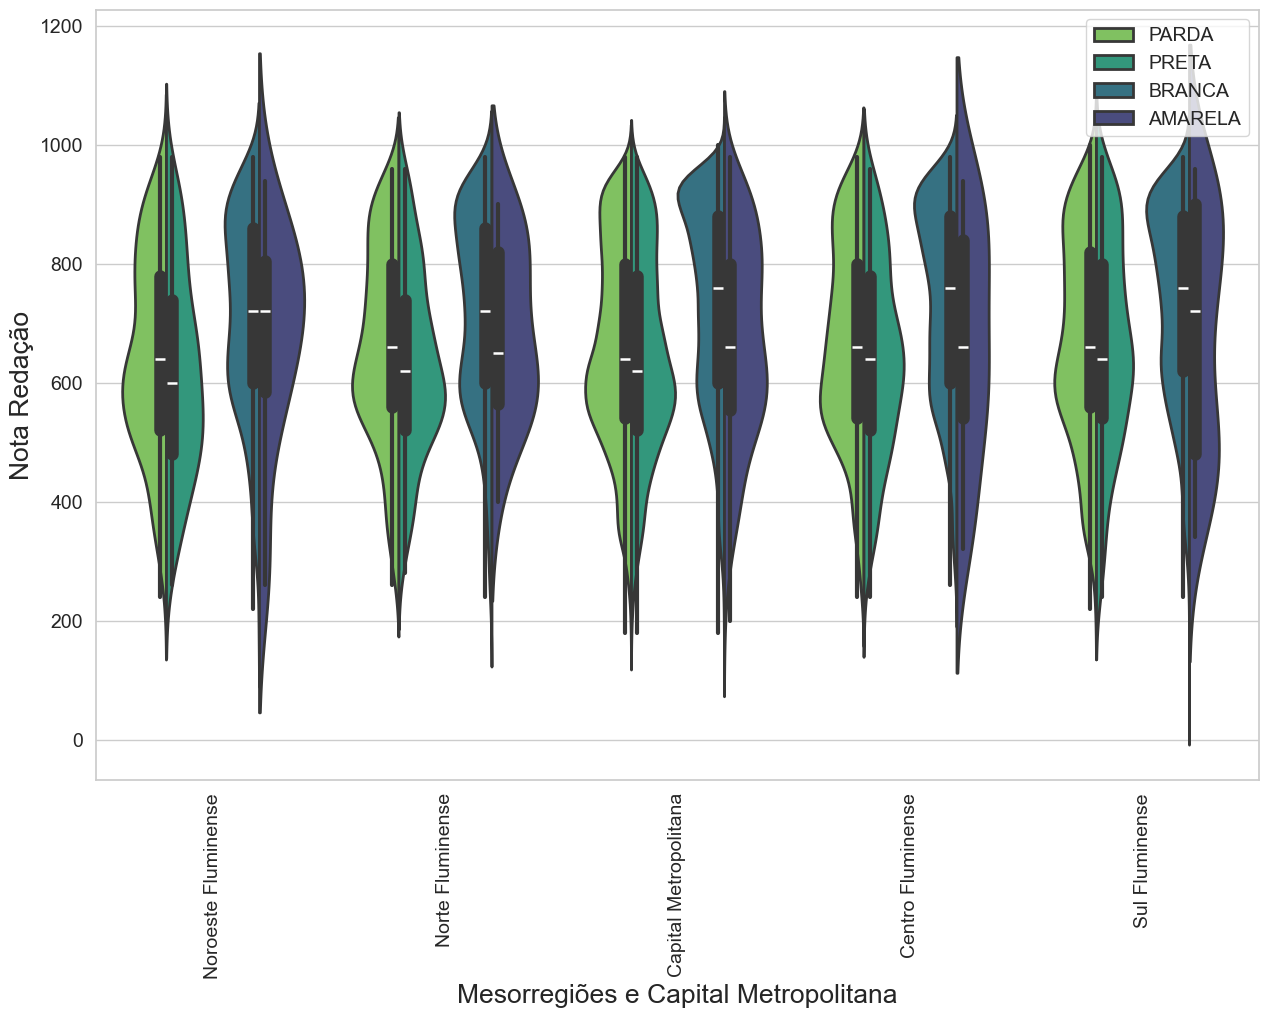

In [272]:
# Ordenando a DataFrame com base na mediana da nota de matemática por mesorregião
medianas = Educacao_enem_bin_mt_muni_02.groupby('Mesorregiao')['NU_NOTA_REDACAO'].median().sort_values()
ordem_categorias = medianas.index

# Ordena o DataFrame baseado em 'Meso_Regiao' e 'Genero'
sorted_df = Educacao_enem_bin_mt_muni_02.sort_values(by=['Mesorregiao', 'TP_SEXO'])

# Criar o gráfico de violino
plt.figure(figsize=(15, 10))
sns.violinplot(data=sorted_df, x='Mesorregiao', y='NU_NOTA_REDACAO', 
               linewidth=2, palette='viridis_r', order=ordem_categorias, hue='TP_SEXO', split=True)
#YlOrBr
# Adicionar uma linha horizontal
#plt.axhline(y=0.00, color='r', linestyle='--', linewidth=2, label='Linha de Referência')

# Customizar o gráfico
plt.ylabel('Nota Matemática', fontsize=19)
plt.xlabel('Mesorregiões e Capital Metropolitana', fontsize=19)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14, rotation=90)

# Opcionalmente adicionar uma legenda
plt.legend(fontsize=14)

medianas = Educacao_enem_bin_mt_muni_02.groupby('Mesorregiao')['NU_NOTA_REDACAO'].median().sort_values()
ordem_categorias = medianas.index

# Ordena o DataFrame baseado em 'Meso_Regiao' e 'Genero'
sorted_df = Educacao_enem_bin_mt_muni_02.sort_values(by=['Mesorregiao', 'TP_SEXO'])

# Criar o gráfico de violino
plt.figure(figsize=(15, 10))
sns.violinplot(data=sorted_df, x='Mesorregiao', y='NU_NOTA_REDACAO', 
               linewidth=2, palette='viridis_r', order=ordem_categorias, hue='TP_COR_RACA', split=True)
#YlOrBr
# Adicionar uma linha horizontal
#plt.axhline(y=0.00, color='r', linestyle='--', linewidth=2, label='Linha de Referência')

# Customizar o gráfico
plt.ylabel('Nota Redação', fontsize=19)
plt.xlabel('Mesorregiões e Capital Metropolitana', fontsize=19)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14, rotation=90)

# Opcionalmente adicionar uma legenda
plt.legend(fontsize=14)


In [ ]:
## índice HII para concentração de notas e desempenho por região